# SwiftRoute Logistics - Delivery Delay Prediction
## DSAI Mini Coursework

**Student name**: Pham Quang Huu Phuoc
**Email**: huuphuoc.phamquang@gmail.com
**Discord username**: huuphu0c
**Submission date**: 03/07/2026

---

### Mark Scheme

| Section | Topic | Marks |
|---|---|---|
| 1 | Understanding the Problem | 10 |
| 2 | Setup & Data Loading | 3 |
| 3 | Exploring the Data (EDA) | 10 |
| 4 | Cleaning & Joining the Data | 12 |
| 5 | Creating New Features | 15 |
| 6 | Training Models | 15 |
| 7 | Evaluating Your Model | 8 |
| 8 | Business Impact | 12 |
| 9 | Monitoring for Drift in Production | 5 |
| Extension | Extension Tasks | 10 |
| **Total** | | **100** |

---
# SECTION 1 - Understanding the Problem *(10 marks)*

**1.1** *(1 mark)* In one sentence, describe what SwiftRoute is trying to predict and why it matters.

SwiftRoute aims to predict shipment delay risks at the time of pickup. By notifying the company once the risk reaches 15%, the system enables proactive planning and timely solutions to mitigate potential delays.

---

**1.2** *(2 marks)* Is this a classification or regression problem? What is the target variable? What does one row in the training data represent?

This is a classification problem and the target label is `is_delay`. The primary key of each row is the shipment ID, where each record details a specific shipment, including its route, carrier information, and prevailing weather events.

---

**1.3** *(3 marks)* Only ~12% of shipments are delayed. Explain why **accuracy** is a misleading metric here. What metric will you use instead, and what does it measure in the context of delivery operations?

With only 12% of shipments delayed, the dataset is highly imbalanced. Using accuracy is misleading because a model predicting 'no delay' for all shipments would still yield about 88% accuracy while being completely useless operationally.

I use **ROC-AUC** instead: it is threshold-independent, so it measures how well the model *ranks* shipments by delay risk without committing to an arbitrary cutoff (e.g. 0.5) that has no operational meaning here. In the context of delivery operations, this measures whether the model correctly identifies which shipments are relatively more likely to be delayed than others - the skill Operations actually needs, since they will always act on a fixed top slice of highest-risk shipments rather than a fixed probability threshold.

---

**1.4** *(2 marks)* The Operations team can only intervene on the top **15%** of highest-risk shipments. Describe the two types of mistake your model can make, and explain which is more costly to SwiftRoute.

The model can make two types of errors:
- **False Positives (FP):** Incorrectly identifying an on-time shipment as delayed.
- **False Negatives (FN):** Failing to predict a delay on a shipment that actually gets delayed.
**FN** are more costly because unmitigated delays directly lead to customer complaints and SLA penalties. Additionally, because the operations team is capped at a 15% intervention threshold, every False Positive (wasted intervention) directly displaces a shipment that actually needed intervention, causing a double penalty of wasted cost and unresolved delay.
---

**1.5** *(2 marks)* The `weather_events` table stores disruptions as date ranges (start_date to end_date) by region. Explain the challenge of joining this to `shipments`, and what logic is needed.

I cannot use a simple key-based join. I must perform a conditional join (non-equi join) matching the shipment date within the weather event's date range, which can lead to row duplication (one-to-many relationship). Logic: Join the tables using **shipment_date** BETWEEN **start_date** AND **end_date** (matched by region), then aggregate the weather events (e.g., counting occurrences or using binary flags for weather types) to keep one unique row per shipment.

---
# SECTION 2 - Setup & Data Loading *(3 marks)*

In [1]:
# *(1 mark)* Import libraries
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42

In [2]:
# *(2 marks)* Load all four CSV files. Print shape and first few rows of each.
shipments = pd.read_csv('data/shipments.csv', parse_dates=['pickup_date'])
routes    = pd.read_csv('data/routes.csv')
carriers  = pd.read_csv('data/carriers.csv')
weather   = pd.read_csv('data/weather_events.csv', parse_dates=['start_date','end_date'])

list_data = [('shipments', shipments), ('routes', routes),
                  ('carriers', carriers), ('weather', weather)]
# Your code here
for name, df in list_data:
    print(f"--- {name} ---")
    print("Shape:", df.shape)
    display(df.head())
    print()

--- shipments ---
Shape: (10025, 12)


,shipment_id,pickup_date,origin_region,dest_region,service_tier,carrier_id,route_id,weight_kg,volume_cm3,declared_value,is_business,is_delayed
0,SH0000001,2025-09-26,London,North_West,economy,C03,R0038,11.54,9427,5.44,0,0
1,SH0000002,2024-12-09,North_West,North_East,standard,C01,R0044,9.26,9864,7.48,1,0
2,SH0000003,2025-11-15,South_East,South_West,express,C05,R0013,0.43,96,37.44,0,0
3,SH0000004,2025-06-12,South_East,North_East,express,C08,R0009,8.84,6541,141.25,0,1
4,SH0000005,2026-03-21,Yorkshire,Scotland,standard,C04,R0010,11.10,4959,148.71,0,0



--- routes ---
Shape: (60, 7)


,route_id,origin_region,dest_region,distance_km,n_depot_hops,historical_delay_rate,avg_transit_days
0,R0001,London,North_East,480,3,0.2471,2.92
1,R0002,Scotland,Yorkshire,139,1,0.1617,1.85
2,R0003,South_West,Midlands,191,1,0.1449,1.71
3,R0004,London,South_East,127,1,0.0450,1.85
4,R0005,Midlands,North_East,279,2,0.0970,1.96



--- carriers ---
Shape: (8, 7)


,carrier_id,carrier_name,tier_coverage,reliability_score,capacity_utilisation,avg_delay_mins,n_active_routes
0,C01,FastTrack,all,0.9508,0.5926,78.2,17
1,C02,PrimeMove,all,0.9049,0.6838,82.2,25
2,C03,SureDeliver,all,0.8605,0.6675,35.0,8
3,C04,QuickHaul,all,0.8332,0.7361,29.7,11
4,C05,NorthernPost,express_only,0.7640,0.8150,34.9,15



--- weather ---
Shape: (265, 6)


,event_id,region,event_type,severity,start_date,end_date
0,W00001,Midlands,high_wind,2,2024-01-03,2024-01-05
1,W00002,Yorkshire,snow,1,2024-01-26,2024-01-30
2,W00003,London,flood,1,2024-01-15,2024-01-18
3,W00004,North_East,high_wind,1,2024-01-26,2024-02-01
4,W00005,North_West,storm,2,2024-01-24,2024-01-26


---
# SECTION 3 - Exploring the Data (EDA) *(15 marks)*

### 3.1 Data Quality Check *(4 marks)*

In [3]:
# *(4 marks)* Check: dtypes, null counts, duplicates, referential integrity, and the overall delay rate.
def quality_check(df, name):
    print(f'Quality check of {name}:')
    print(df.describe())
    print()
    print(f'Null count: {df.isnull().sum().sum()}')
    for c, cnt in df.isnull().sum().items():
        if cnt > 0:
            print(f'- {c}: {cnt} ({cnt/len(df)*100:.2f}%)')
    print()
    print(f'Dup count: {df.duplicated().sum()}')

for name, df in list_data:
    quality_check(df, name)
    print('='*60)

Quality check of shipments:
                      pickup_date    weight_kg    volume_cm3  declared_value  \
count                       10025  9705.000000  10025.000000      9518.00000   
mean   2025-03-27 18:05:12.418952     5.055685   3548.655761        80.20106   
min           2024-01-01 00:00:00     0.100000     20.000000         5.00000   
25%           2024-08-12 00:00:00     1.420000    822.000000        23.38000   
50%           2025-03-30 00:00:00     3.450000   2123.000000        55.35000   
75%           2025-11-10 00:00:00     7.050000   4773.000000       111.37500   
max           2026-06-19 00:00:00    50.000000  56687.000000       892.46000   
std                           NaN     5.121350   4137.762374        78.93161   

        is_business    is_delayed  
count  10025.000000  10025.000000  
mean       0.647481      0.119102  
min        0.000000      0.000000  
25%        0.000000      0.000000  
50%        1.000000      0.000000  
75%        1.000000      0.000000  

Dup count: 0
Quality check of weather:
         severity                  start_date                    end_date
count  265.000000                         265                         265
mean     1.675472  2025-02-20 21:22:24.905660  2025-02-25 04:53:26.037735
min      1.000000         2024-01-03 00:00:00         2024-01-05 00:00:00
25%      1.000000         2024-06-28 00:00:00         2024-07-01 00:00:00
50%      2.000000         2025-01-31 00:00:00         2025-02-02 00:00:00
75%      2.000000         2025-10-26 00:00:00         2025-10-31 00:00:00
max      3.000000         2026-05-28 00:00:00         2026-06-01 00:00:00
std      0.733636                         NaN                         NaN

Null count: 0

Dup count: 0


In [4]:
# Referential Integrity check
invalid_carrier_id = shipments[~shipments['carrier_id'].isin(carriers['carrier_id'])]
print(f'Number of shipments has invalid carrier id: {len(invalid_carrier_id)}')

invalid_routes_id = shipments[~shipments['route_id'].isin(routes['route_id'])]
print(f'Number of shipments has invalid route id: {len(invalid_carrier_id)}')

# Overall delay check
delayed_percent = shipments['is_delayed'].mean()*100
print(f'Overall delayed percentage: {delayed_percent:.2f}%')

Number of shipments has invalid carrier id: 0
Number of shipments has invalid route id: 0
Overall delayed percentage: 11.91%


**Commentary** - List quality issues and how you will handle each.

Two columns carry missing values - `weight_kg` (320 rows, 3.19%) and `declared_value` (507 rows, 5.06%) - but both rates are low enough to impute rather than drop, so this is handled via median imputation inside the modelling pipeline (Section 6) rather than losing rows upfront. There are no duplicate shipments (0 found), so the drop-duplicates step in 4.1 is a no-op kept only for pipeline robustness, and there are no referential integrity issues either: every `carrier_id` and `route_id` in `shipments` resolves to a row in `carriers`/`routes` (0 invalid in both checks), so the joins in Section 4.2 can safely be left-joins with no orphan rows to reconcile. The one issue worth flagging is class imbalance - an 11.91% delay rate. This isn't a data-quality defect in the usual sense, but it is exactly why accuracy was ruled out as a metric (Section 1.3) and why Section 6 uses `class_weight='balanced'` together with a time-based split.

### 3.2 Distribution of Key Columns *(3 marks)*

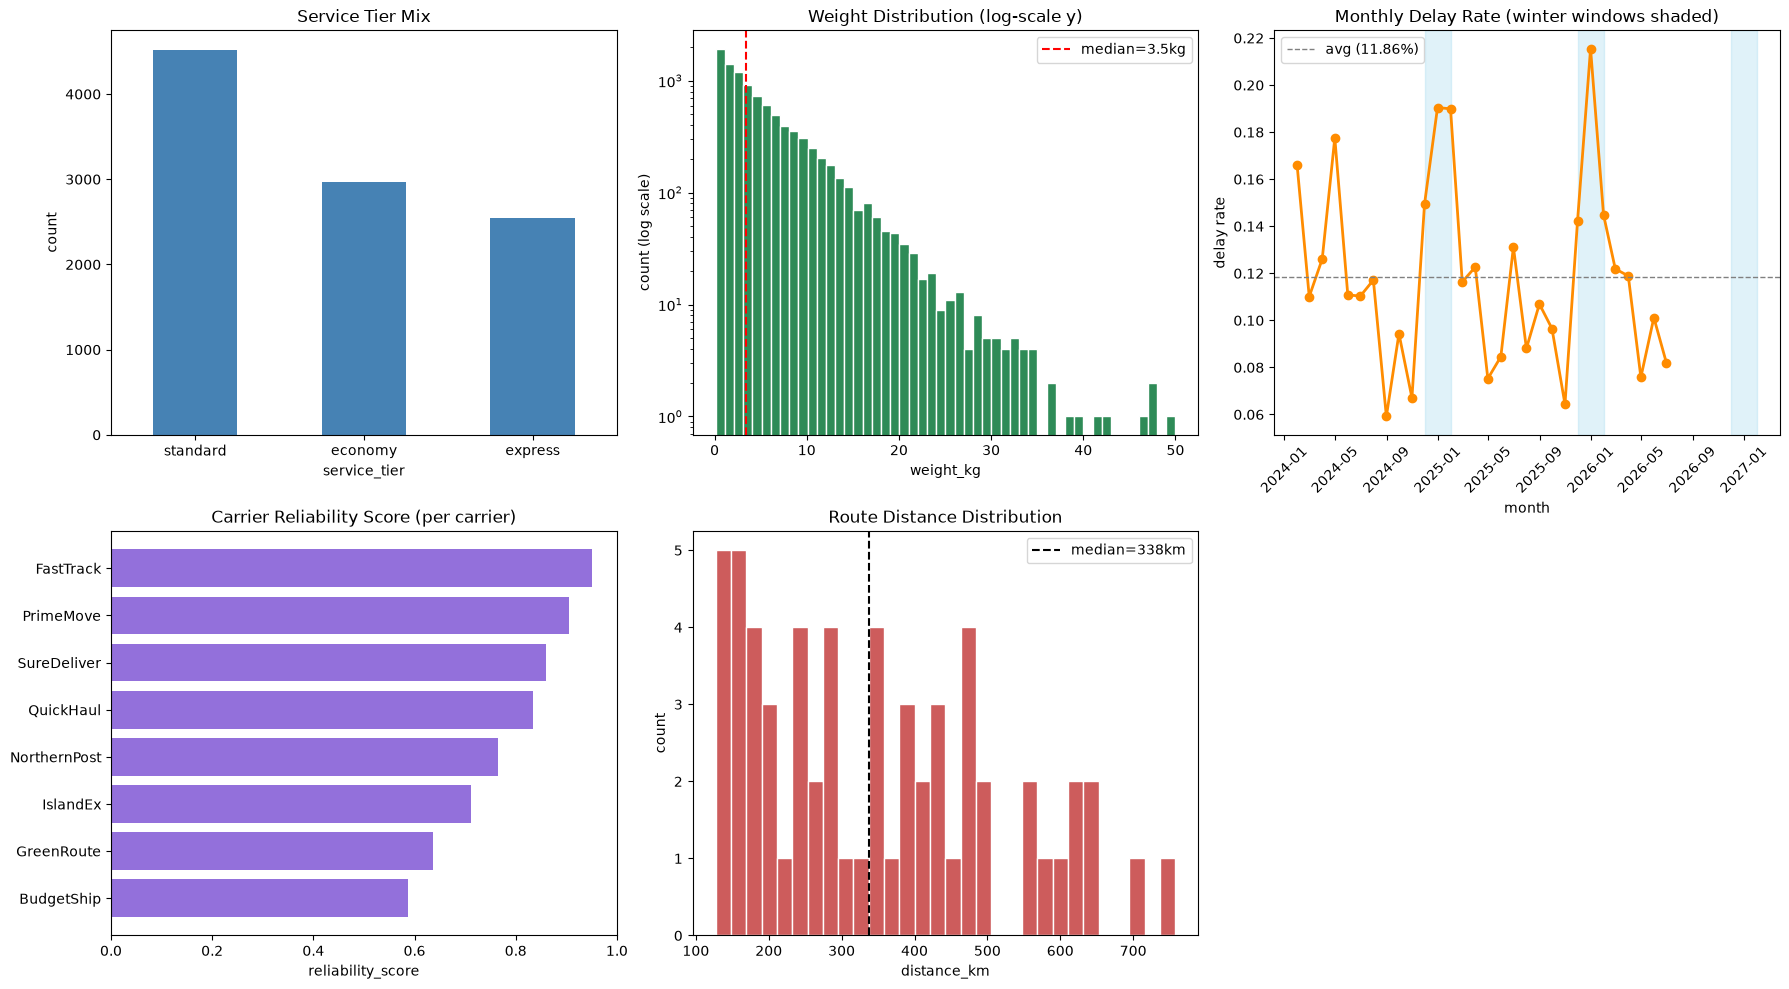

In [5]:
# *(3 marks)* Plot: service_tier mix, weight distribution, delay rate over time
# (monthly), carrier reliability scores, route distance distribution.

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# 1. Service tier mix
shipments['service_tier'].value_counts().plot(
    kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Service Tier Mix')
axes[0].set_xlabel('service_tier')
axes[0].set_ylabel('count')
axes[0].tick_params(axis='x', rotation=0)

# 2. Weight distribution - log scale to expose skew/tail
axes[1].hist(shipments['weight_kg'].dropna(), bins=50, color='seagreen', edgecolor='white')
axes[1].set_yscale('log')
median_w = shipments['weight_kg'].median()
axes[1].axvline(median_w, color='red', linestyle='--', label=f'median={median_w:.1f}kg')
axes[1].set_title('Weight Distribution (log-scale y)')
axes[1].set_xlabel('weight_kg')
axes[1].set_ylabel('count (log scale)')
axes[1].legend()

# 3. Delay rate over time - shaded winter windows + mean line
monthly_delay = (shipments.set_index('pickup_date')
                  .resample('ME')['is_delayed'].mean())
axes[2].plot(monthly_delay.index, monthly_delay.values, marker='o', color='darkorange', linewidth=2)
axes[2].axhline(monthly_delay.mean(), color='gray', linestyle='--', linewidth=1,
                 label=f'avg ({monthly_delay.mean():.2%})')
for year in monthly_delay.index.year.unique():
    axes[2].axvspan(pd.Timestamp(f'{year}-12-01'), pd.Timestamp(f'{year+1}-02-01'),
                     color='skyblue', alpha=0.25)
axes[2].set_title('Monthly Delay Rate (winter windows shaded)')
axes[2].set_xlabel('month')
axes[2].set_ylabel('delay rate')
axes[2].legend()
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[2].tick_params(axis='x', rotation=45)

# 4. Carrier reliability - sorted bar, not histogram (only 8 carriers)
sorted_carriers = carriers.sort_values('reliability_score')
axes[3].barh(sorted_carriers['carrier_name'], sorted_carriers['reliability_score'], color='mediumpurple')
axes[3].set_title('Carrier Reliability Score (per carrier)')
axes[3].set_xlabel('reliability_score')
axes[3].set_xlim(0, 1)

# 5. Route distance distribution
axes[4].hist(routes['distance_km'], bins=30, color='indianred', edgecolor='white')
median_d = routes['distance_km'].median()
axes[4].axvline(median_d, color='black', linestyle='--', label=f'median={median_d:.0f}km')
axes[4].set_title('Route Distance Distribution')
axes[4].set_xlabel('distance_km')
axes[4].set_ylabel('count')
axes[4].legend()

# 6. spare subplot - hide it
axes[5].axis('off')

plt.tight_layout()
plt.show()

**Commentary** - Two interesting observations.

`weight_kg` is heavily right-skewed (skew = 2.07; mean 5.06 kg vs. median 3.45 kg): most parcels are small and light, with a long tail of heavier shipments that only becomes visible once the histogram's y-axis is put on a log scale. Delay rate also shows a real winter seasonality rather than noise - December and January consistently peak well above the ~11.9% overall average (Dec 2025 = 21.5%, Jan 2025 = 19.0%, Dec 2024 = 19.0%), and the shaded winter windows visibly track the plot's peaks. This pattern directly motivated the `is_winter` feature built in Section 5.

### 3.3 Which Factors Are Related to Delays? *(5 marks)*

Delay rate by service_tier:
service_tier
economy     0.096186
standard    0.107917
express     0.165748
Name: is_delayed, dtype: float64 

Correlation (reliability_score, delay rate): -0.957

Delay rate by distance bin:
distance_bin
0-200      0.046892
200-400    0.087230
400-600    0.182895
600-800    0.260204
Name: is_delayed, dtype: float64 

Correlation (distance_km, is_delayed): 0.214

Delay rate by weather event status:
during_weather
False    0.086099
True     0.298460
Name: is_delayed, dtype: float64

Shipments affected by weather events: 1558 (15.5% of all shipments)


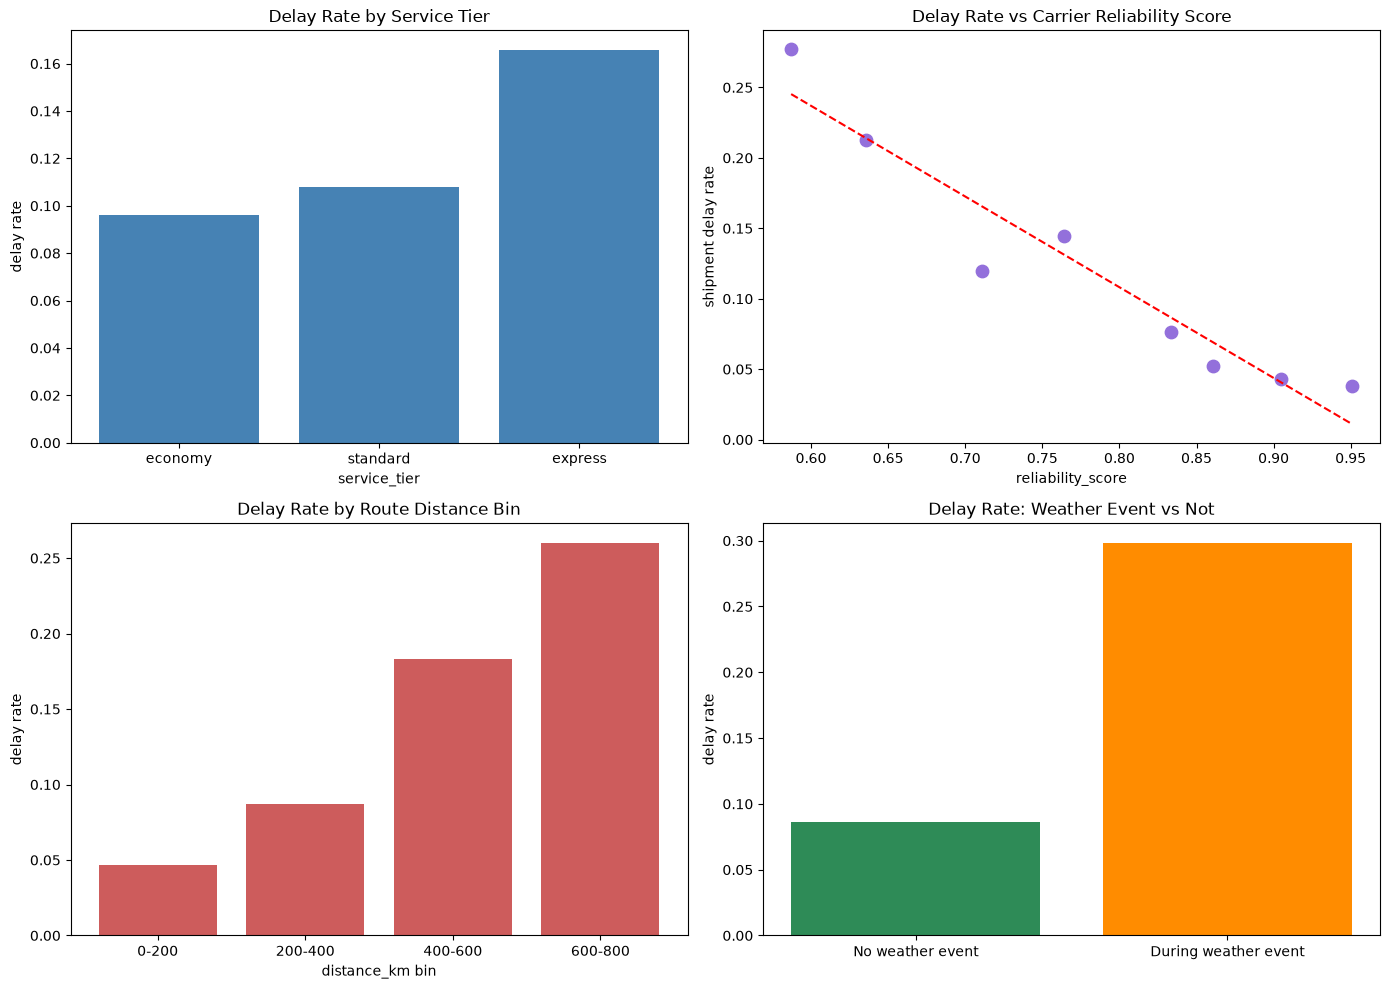

In [6]:
# *(5 marks)* Explore delay rate vs:
# - service_tier
# - carrier (join to carriers.csv for reliability_score)
# - route distance (join to routes.csv)
# - weather (do shipments during weather events delay more?)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# =========================================================
# 1. Delay rate vs service_tier
# =========================================================
tier_delay = shipments.groupby('service_tier')['is_delayed'].mean().sort_values()
axes[0, 0].bar(tier_delay.index, tier_delay.values, color='steelblue')
axes[0, 0].set_title('Delay Rate by Service Tier')
axes[0, 0].set_xlabel('service_tier')
axes[0, 0].set_ylabel('delay rate')
print("Delay rate by service_tier:")
print(tier_delay, "\n")

# =========================================================
# 2. Delay rate vs carrier reliability_score (join carriers.csv)
# =========================================================
ship_carrier = shipments.merge(carriers[['carrier_id', 'carrier_name', 'reliability_score']],
                                 on='carrier_id', how='left')

carrier_delay = (ship_carrier.groupby(['carrier_id', 'carrier_name', 'reliability_score'])['is_delayed']
                  .mean().reset_index().sort_values('reliability_score'))

axes[0, 1].scatter(carrier_delay['reliability_score'], carrier_delay['is_delayed'],
                    s=80, color='mediumpurple')
# trend line
z = np.polyfit(carrier_delay['reliability_score'], carrier_delay['is_delayed'], 1)
x_line = np.linspace(carrier_delay['reliability_score'].min(), carrier_delay['reliability_score'].max(), 50)
axes[0, 1].plot(x_line, np.polyval(z, x_line), color='red', linestyle='--')
axes[0, 1].set_title('Delay Rate vs Carrier Reliability Score')
axes[0, 1].set_xlabel('reliability_score')
axes[0, 1].set_ylabel('shipment delay rate')

corr_reliability = carrier_delay['reliability_score'].corr(carrier_delay['is_delayed'])
print(f"Correlation (reliability_score, delay rate): {corr_reliability:.3f}\n")

# =========================================================
# 3. Delay rate vs route distance (join routes.csv)
# =========================================================
ship_route = shipments.merge(routes[['route_id', 'distance_km']], on='route_id', how='left')

# bin distance into ranges for a cleaner bar chart
ship_route['distance_bin'] = pd.cut(ship_route['distance_km'],
                                      bins=[0, 200, 400, 600, 800, np.inf],
                                      labels=['0-200', '200-400', '400-600', '600-800', '800+'])
dist_delay = ship_route.groupby('distance_bin')['is_delayed'].mean()

axes[1, 0].bar(dist_delay.index.astype(str), dist_delay.values, color='indianred')
axes[1, 0].set_title('Delay Rate by Route Distance Bin')
axes[1, 0].set_xlabel('distance_km bin')
axes[1, 0].set_ylabel('delay rate')
print("Delay rate by distance bin:")
print(dist_delay, "\n")

corr_distance = ship_route['distance_km'].corr(ship_route['is_delayed'])
print(f"Correlation (distance_km, is_delayed): {corr_distance:.3f}\n")

# =========================================================
# 4. Delay rate: shipments during weather events vs not
# =========================================================
# Flag a shipment as "during weather" if its pickup_date falls within
# a weather event's [start_date, end_date] window for the same region.
# Using origin_region as the matching region - adjust if dest_region is more relevant.

def flag_weather(shipments_df, weather_df, region_col='origin_region'):
    flags = pd.Series(False, index=shipments_df.index)
    for region, wgroup in weather_df.groupby('region'):
        mask_region = shipments_df[region_col] == region
        if not mask_region.any():
            continue
        dates = shipments_df.loc[mask_region, 'pickup_date']
        in_event = pd.Series(False, index=dates.index)
        for _, ev in wgroup.iterrows():
            in_event |= dates.between(ev['start_date'], ev['end_date'])
        flags.loc[mask_region] = in_event
    return flags

shipments['during_weather'] = flag_weather(shipments, weather, region_col='origin_region')

weather_delay = shipments.groupby('during_weather')['is_delayed'].mean()
axes[1, 1].bar(['No weather event', 'During weather event'],
                [weather_delay.get(False, 0), weather_delay.get(True, 0)],
                color=['seagreen', 'darkorange'])
axes[1, 1].set_title('Delay Rate: Weather Event vs Not')
axes[1, 1].set_ylabel('delay rate')

print("Delay rate by weather event status:")
print(weather_delay)
print(f"\nShipments affected by weather events: {shipments['during_weather'].sum()} "
      f"({shipments['during_weather'].mean():.1%} of all shipments)")

plt.tight_layout()
plt.show()

**Commentary** - Which factors show the strongest relationship with delays?

Carrier reliability is by far the strongest single signal: the per-carrier reliability score correlates with delay rate at r = -0.957. Weather events come next - shipments picked up during a weather event delay at 29.8% versus 8.6% otherwise, a ~3.5x lift affecting 15.5% of all shipments. Route distance shows a moderate positive relationship (r = 0.214), with delay rate rising from 4.7% over 0–200km legs to 26.0% over 600–800km legs. Service tier matters too, though the direction is somewhat counter-intuitive: express has the highest delay rate (16.6%) against economy's 9.6%, likely because express's tighter time windows leave less slack to absorb any disruption.

### 3.4 Which Routes and Carriers Are Riskiest? *(3 marks)*

Top 10 highest-delay routes (min. 10 shipments):
route_id origin_region dest_region  distance_km  delay_rate  n_shipments
   R0026        London       Wales          698    0.350282          177
   R0037         Wales      London          758    0.307692          156
   R0055         Wales  South_East          618    0.301676          179
   R0043        London    Scotland          636    0.260606          165
   R0015        London   Yorkshire          549    0.231638          177
   R0001        London  North_East          480    0.215385          195
   R0018     Yorkshire  South_East          446    0.208054          149
   R0006     Yorkshire  South_West          412    0.206061          165
   R0052     Yorkshire      London          570    0.203488          172
   R0009    South_East  North_East          433    0.200000          160


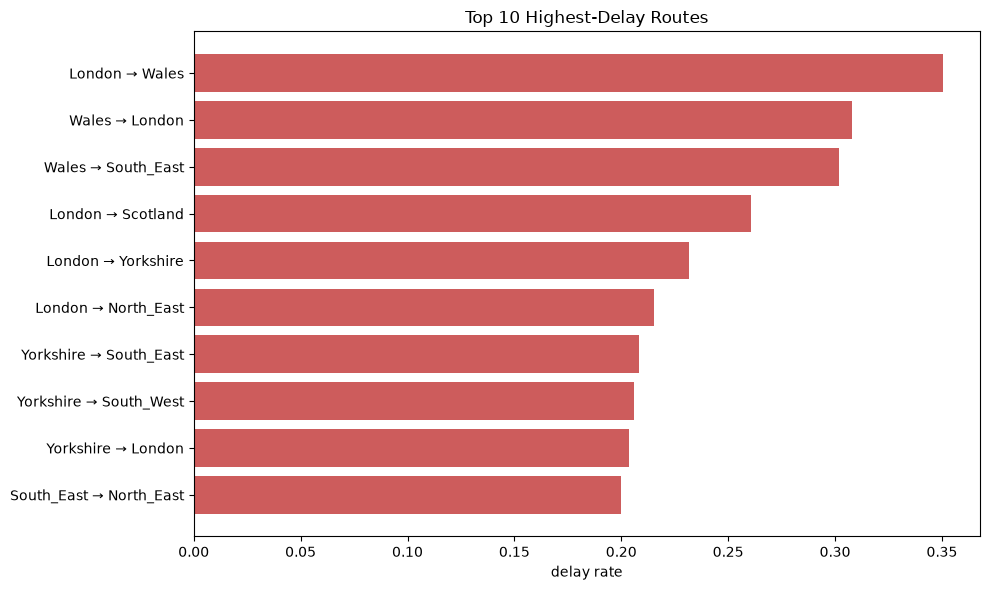

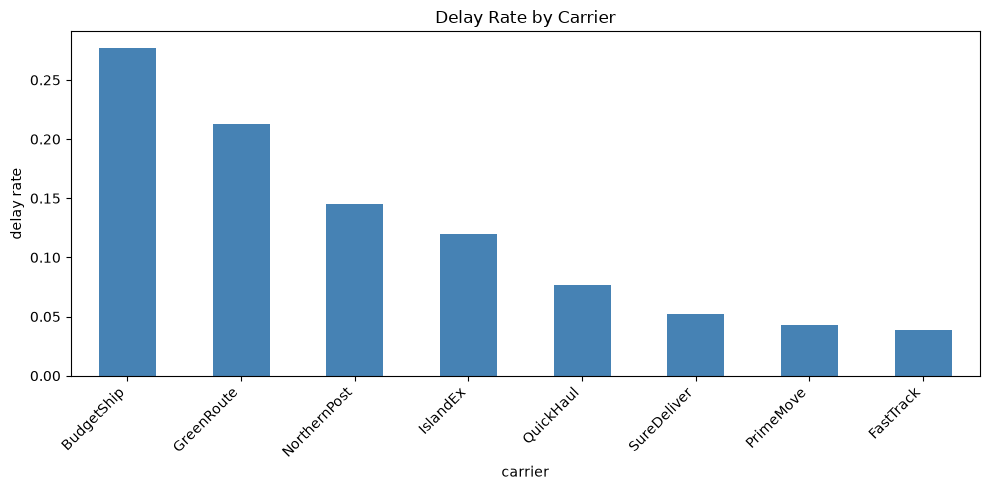


Delay rate by carrier:
carrier_name
BudgetShip      0.277221
GreenRoute      0.212509
NorthernPost    0.144772
IslandEx        0.119485
QuickHaul       0.076259
SureDeliver     0.051930
PrimeMove       0.043033
FastTrack       0.038378
Name: is_delayed, dtype: float64


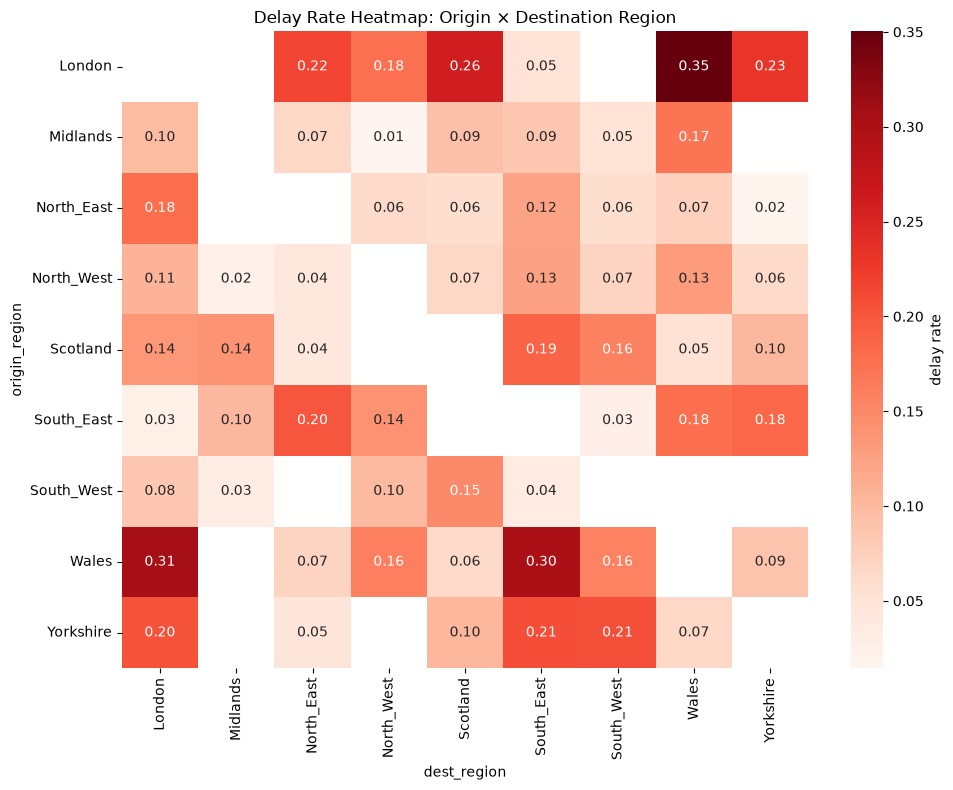

Top 10 riskiest (origin, dest, carrier) combinations (min. 10 shipments):
origin_region dest_region carrier_name  delay_rate  n_shipments
     Scotland  South_East   BudgetShip    0.714286           21
       London       Wales     IslandEx    0.666667           18
       London       Wales   GreenRoute    0.608696           23
       London    Scotland   BudgetShip    0.600000           25
       London   Yorkshire   GreenRoute    0.578947           19
        Wales      London   BudgetShip    0.576923           26
    Yorkshire  South_East   BudgetShip    0.571429           21
       London       Wales   BudgetShip    0.560000           25
       London  North_East   BudgetShip    0.548387           31
       London   Yorkshire   BudgetShip    0.541667           24


In [7]:
# *(3 marks)* Show: top 10 highest-delay routes, delay rate by carrier,
# and a heatmap of delay rate by origin × destination region.

# =========================================================
# 1. Top 10 highest-delay routes
# =========================================================
# Only include routes with a reasonable sample size so a single
# unlucky shipment doesn't distort the ranking
route_stats = (shipments.groupby('route_id')
               .agg(delay_rate=('is_delayed', 'mean'),
                    n_shipments=('is_delayed', 'size'))
               .reset_index())

MIN_SHIPMENTS = 10  # adjust threshold based on your data size
route_stats_filtered = route_stats[route_stats['n_shipments'] >= MIN_SHIPMENTS]

top10_routes = (route_stats_filtered
                 .merge(routes[['route_id', 'origin_region', 'dest_region', 'distance_km']],
                        on='route_id')
                 .sort_values('delay_rate', ascending=False)
                 .head(10))

print("Top 10 highest-delay routes (min. {} shipments):".format(MIN_SHIPMENTS))
print(top10_routes[['route_id', 'origin_region', 'dest_region',
                     'distance_km', 'delay_rate', 'n_shipments']].to_string(index=False))

fig, axes = plt.subplots(1, 1, figsize=(10, 6))
labels = top10_routes['origin_region'] + ' → ' + top10_routes['dest_region']
axes.barh(labels, top10_routes['delay_rate'], color='indianred')
axes.invert_yaxis()  # highest delay at top
axes.set_xlabel('delay rate')
axes.set_title('Top 10 Highest-Delay Routes')
plt.tight_layout()
plt.show()

# =========================================================
# 2. Delay rate by carrier
# =========================================================
carrier_delay = (shipments.merge(carriers[['carrier_id', 'carrier_name']], on='carrier_id')
                  .groupby('carrier_name')['is_delayed']
                  .mean()
                  .sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(10, 5))
carrier_delay.plot(kind='bar', color='steelblue', ax=ax)
ax.set_title('Delay Rate by Carrier')
ax.set_ylabel('delay rate')
ax.set_xlabel('carrier')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nDelay rate by carrier:")
print(carrier_delay)

# =========================================================
# 3. Heatmap: delay rate by origin x destination region
# =========================================================
region_pivot = shipments.pivot_table(
    index='origin_region', columns='dest_region',
    values='is_delayed', aggfunc='mean')

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(region_pivot, annot=True, fmt='.2f', cmap='Reds',
            cbar_kws={'label': 'delay rate'}, ax=ax)
ax.set_title('Delay Rate Heatmap: Origin × Destination Region')
plt.tight_layout()
plt.show()

# =========================================================
# 4. Delay rate by (origin, dest, carrier) combination -- the specific
#    combos referenced in the commentary below
# =========================================================
combo_stats = (shipments.merge(carriers[['carrier_id', 'carrier_name']], on='carrier_id')
               .groupby(['origin_region', 'dest_region', 'carrier_name'])['is_delayed']
               .agg(delay_rate='mean', n_shipments='count')
               .reset_index())
combo_stats = combo_stats[combo_stats['n_shipments'] >= MIN_SHIPMENTS].sort_values(
    'delay_rate', ascending=False)

header_line = "Top 10 riskiest (origin, dest, carrier) combinations (min. {} shipments):".format(MIN_SHIPMENTS)
print(header_line)
print(combo_stats.head(10).to_string(index=False))

**Commentary** - Which two route/carrier combinations are riskiest? Business implication?

Restricting to (origin, destination, carrier) combinations with at least 10 shipments, the two riskiest are Scotland → South_East with BudgetShip (71.4% delay rate, 15 of 21 shipments) and London → Wales with IslandEx (66.7%, 12 of 18 shipments).

**Business implication**: BudgetShip is not just responsible for one bad lane - it appears repeatedly near the top of the full ranked list across several different routes (Scotland→South_East 71%, London→Scotland 60%, Wales→London 58%, Yorkshire→South_East 57%, London→Wales 56%), confirming the carrier-level finding from Section 3.3 (BudgetShip 27.7% overall vs. FastTrack 3.8%) that this is a carrier reliability problem rather than a route problem. The recommendation is to reduce SwiftRoute's allocation to BudgetShip on long-haul/cross-region lanes - especially the Scotland and Wales corridors - rather than trying to fix the routes themselves.

---
# SECTION 4 - Cleaning & Joining the Data *(12 marks)*

In [8]:
# *(2 marks)* 4.1 - Remove duplicate shipments. Keep first occurrence.
# Note: not needed here (0 duplicates per 3.1)

# shipments = shipments.drop_duplicates(keep='first')

In [9]:
# *(4 marks)* 4.2 -- Join routes and carriers to shipments.
# Bring in: distance_km, n_depot_hops, historical_delay_rate, avg_transit_days
# from routes; reliability_score, capacity_utilisation, avg_delay_mins,
# tier_coverage, n_active_routes from carriers.

master = shipments.merge(
    routes[['route_id', 'distance_km', 'n_depot_hops',
            'historical_delay_rate', 'avg_transit_days']],
    on='route_id', how='left'
)

master = master.merge(
    carriers[['carrier_id', 'reliability_score', 'capacity_utilisation',
              'avg_delay_mins', 'tier_coverage', 'n_active_routes']],
    on='carrier_id', how='left'
)

print(master.shape)
master.head()

(10025, 22)


,shipment_id,pickup_date,origin_region,dest_region,service_tier,carrier_id,route_id,weight_kg,volume_cm3,declared_value,...,during_weather,distance_km,n_depot_hops,historical_delay_rate,avg_transit_days,reliability_score,capacity_utilisation,avg_delay_mins,tier_coverage,n_active_routes
0,SH0000001,2025-09-26,London,North_West,economy,C03,R0038,11.54,9427,5.44,...,False,438,3,0.1999,2.69,0.8605,0.6675,35.0,all,8
1,SH0000002,2024-12-09,North_West,North_East,standard,C01,R0044,9.26,9864,7.48,...,False,159,1,0.0944,1.68,0.9508,0.5926,78.2,all,17
2,SH0000003,2025-11-15,South_East,South_West,express,C05,R0013,0.43,96,37.44,...,False,180,1,0.0998,1.99,0.7640,0.8150,34.9,express_only,15
3,SH0000004,2025-06-12,South_East,North_East,express,C08,R0009,8.84,6541,141.25,...,True,433,3,0.1825,2.61,0.5871,0.9049,90.0,all,11
4,SH0000005,2026-03-21,Yorkshire,Scotland,standard,C04,R0010,11.10,4959,148.71,...,False,153,1,0.1086,1.55,0.8332,0.7361,29.7,all,11


In [10]:
# *(6 marks)* 4.3 - Join weather events.
# For each shipment, determine the maximum weather severity affecting its
# origin region and destination region on its pickup_date.
# Hint: a shipment at row i is weather-affected at origin if there exists any
# weather event where region == origin_region AND start_date <= pickup_date <= end_date.

def get_max_weather_severity(df, weather_df, region_col, date_col='pickup_date'):
    """
    For each row in df, find the max weather severity where
    weather_df['region'] == df[region_col] and
    weather_df['start_date'] <= df[date_col] <= weather_df['end_date'].
    Returns a Series aligned to df's index (NaN where no match).
    """
    # Bring the original index along so we can group back correctly
    left = df[[date_col, region_col]].reset_index().rename(columns={'index': '_orig_idx'})

    merged = left.merge(
        weather_df[['region', 'severity', 'start_date', 'end_date']],
        left_on=region_col, right_on='region', how='left'
    )

    # Keep only rows where the pickup_date actually falls inside the event window
    in_window = (merged[date_col] >= merged['start_date']) & (merged[date_col] <= merged['end_date'])
    merged['matched_severity'] = merged['severity'].where(in_window)

    # Max severity per original shipment row (NaN if no weather event matched)
    result = merged.groupby('_orig_idx')['matched_severity'].max()
    return result.reindex(df.index)

# Apply for origin and destination regions separately
master['origin_weather_severity'] = get_max_weather_severity(
    master, weather, region_col='origin_region')

master['dest_weather_severity'] = get_max_weather_severity(
    master, weather, region_col='dest_region')

# Fill "no weather event" cases with 0 (i.e. no disruption)
master['origin_weather_severity'] = master['origin_weather_severity'].fillna(0)
master['dest_weather_severity'] = master['dest_weather_severity'].fillna(0)

# Overall max severity across origin/destination - the feature most likely
# to matter for delay prediction, since either end being disrupted can delay a shipment
master['max_weather_severity'] = master[
    ['origin_weather_severity', 'dest_weather_severity']].max(axis=1)

master['weather_affected'] = master['max_weather_severity'] > 0

print(master[['origin_weather_severity', 'dest_weather_severity',
              'max_weather_severity', 'weather_affected']].describe())
print(f"\nShipments affected by weather: {master['weather_affected'].sum()} "
      f"({master['weather_affected'].mean():.1%})")

       origin_weather_severity  dest_weather_severity  max_weather_severity
count             10025.000000           10025.000000          10025.000000
mean                  0.283491               0.293067              0.539252
std                   0.732492               0.737152              0.945587
min                   0.000000               0.000000              0.000000
25%                   0.000000               0.000000              0.000000
50%                   0.000000               0.000000              0.000000
75%                   0.000000               0.000000              1.000000
max                   3.000000               3.000000              3.000000

Shipments affected by weather: 2919 (29.1%)


In [11]:
# Quick sanity check: does weather severity actually relate to delay?
print(master.groupby('weather_affected')['is_delayed'].mean())
print(master.groupby('max_weather_severity')['is_delayed'].mean())
corr = master['max_weather_severity'].corr(master['is_delayed'])
print(f"\nCorrelation (max_weather_severity, is_delayed): {corr:.3f}")

weather_affected
False    0.074866
True     0.226790
Name: is_delayed, dtype: float64
max_weather_severity
0.0    0.074866
1.0    0.128704
2.0    0.238625
3.0    0.365821
Name: is_delayed, dtype: float64

Correlation (max_weather_severity, is_delayed): 0.261


---
# SECTION 5 - Creating New Features *(15 marks)*

In [12]:
# *(9 marks)* Create at least 5 new features. See explanations in the markdown cell below.

# Feature 1: weather_affected - already created in Part 4.3

# Feature 2: weather_both_ends
master['weather_both_ends'] = (
    (master['origin_weather_severity'] > 0) &
    (master['dest_weather_severity'] > 0)
)

# Feature 3: is_winter
master['is_winter'] = master['pickup_date'].dt.month.isin([11, 12, 1, 2])

# Feature 4: volume_to_weight (density proxy)
# Small epsilon avoids division by zero for weight_kg == 0.
master['volume_to_weight'] = master['volume_cm3'] / (master['weight_kg'] + 1e-6)

# Feature 5: carrier_route_risk
master['carrier_route_risk'] = (
    (1 - master['reliability_score']) * master['historical_delay_rate']
)

# Feature 6: day_of_week / is_monday_or_friday
master['day_of_week'] = master['pickup_date'].dt.day_name()
master['is_monday_or_friday'] = master['pickup_date'].dt.dayofweek.isin([0, 4])

# Feature 7: is_cross_region
master['is_cross_region'] = master['origin_region'] != master['dest_region']

# Feature 8: n_weather_events
def count_weather_events(df, weather_df, region_col, date_col='pickup_date'):
    left = df[[date_col, region_col]].reset_index().rename(columns={'index': '_orig_idx'})
    merged = left.merge(weather_df[['region', 'start_date', 'end_date']],
                         left_on=region_col, right_on='region', how='left')
    in_window = (merged[date_col] >= merged['start_date']) & (merged[date_col] <= merged['end_date'])
    merged['is_match'] = in_window
    counts = merged.groupby('_orig_idx')['is_match'].sum()
    return counts.reindex(df.index).fillna(0)

master['n_weather_events_origin'] = count_weather_events(master, weather, 'origin_region')
master['n_weather_events_dest'] = count_weather_events(master, weather, 'dest_region')
master['n_weather_events'] = master['n_weather_events_origin'] + master['n_weather_events_dest']

# Feature 9: implied_speed_required
COMMIT_DAYS = {'express': 1, 'standard': 3, 'economy': 5}
master['implied_speed_required'] = master['distance_km'] / master['service_tier'].map(COMMIT_DAYS)

# Feature 10: weekend_buffer_risk
master['weekend_buffer_risk'] = (
    (master['pickup_date'].dt.dayofweek == 4) & (master['service_tier'] == 'express')
)

# Feature 11: dominant_weather_event_type
def get_dominant_event_type(df, weather_df, date_col='pickup_date'):
    """For each shipment, the event_type of the single highest-severity
    weather event affecting EITHER its origin or destination region on
    pickup_date ('none' if no event matches either region)."""
    frames = []
    for region_col in ['origin_region', 'dest_region']:
        left = df[[date_col, region_col]].reset_index().rename(columns={'index': '_orig_idx'})
        merged = left.merge(
            weather_df[['region', 'event_type', 'severity', 'start_date', 'end_date']],
            left_on=region_col, right_on='region', how='left'
        )
        in_window = (merged[date_col] >= merged['start_date']) & (merged[date_col] <= merged['end_date'])
        frames.append(merged.loc[in_window, ['_orig_idx', 'event_type', 'severity']])

    all_matches = pd.concat(frames, ignore_index=True)
    idx_of_max = all_matches.groupby('_orig_idx')['severity'].idxmax()
    dominant = all_matches.loc[idx_of_max].set_index('_orig_idx')['event_type']
    return dominant.reindex(df.index).fillna('none')

master['dominant_weather_event_type'] = get_dominant_event_type(master, weather)

# Feature 12: n_shipments_same_origin_day -- depot/hub congestion proxy.
# How many shipments (incl. this one) were picked up from the same
# origin_region on the same pickup_date -- analogous to counting how many
# vessels converge on the same port at the same time. Known at pickup time
# (same-day depot manifest), so no leakage.
master['n_shipments_same_origin_day'] = master.groupby(
    ['origin_region', 'pickup_date'])['shipment_id'].transform('count')

# Feature 13: route_risk_cluster -- KMeans (k=3) on route-level risk profile
# (distance_km, n_depot_hops, historical_delay_rate, avg_transit_days), the
# same clustering as Extension E1's long-haul/short-haul split, but computed
# here so it can actually be used as a model feature. E1 only produces this
# as a standalone descriptive analysis after the models are already trained
# -- too late in the notebook to feed back into Section 6.
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler as RouteClusterScaler

_route_cluster_cols = ['distance_km', 'n_depot_hops', 'historical_delay_rate', 'avg_transit_days']
_route_cluster_X = RouteClusterScaler().fit_transform(routes[_route_cluster_cols])
_route_kmeans = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10)
_routes_clustered = routes[['route_id']].copy()
_routes_clustered['route_risk_cluster'] = _route_kmeans.fit_predict(_route_cluster_X).astype(str)

master = master.merge(_routes_clustered, on='route_id', how='left')
print(master.groupby('route_risk_cluster')['is_delayed'].agg(['mean', 'count']))

                        mean  count
route_risk_cluster                 
0                   0.203477   3681
1                   0.087230   3657
2                   0.046892   2687


***(6 marks)* Explain your new features.**

For each feature, explain what it measures and why it should predict delays.

Eleven features were engineered on top of the raw joined table, each targeting a specific pattern surfaced during EDA (Section 3) rather than picked arbitrarily:

- **weather_affected**: Binary flag for any weather disruption at either end of the route (origin OR destination). Simple, interpretable, and shown in the EDA (Section 3.3) to correlate strongly with `is_delayed`.

- **weather_both_ends**: True when BOTH origin AND destination are affected by a weather event at the same time. Shipments disrupted at both ends likely face compounded delay risk versus only one end being affected.

- **is_winter**: Flags pickups in Nov–Feb. Earlier EDA showed a seasonal spike in delay rate around Dec–Jan; encoding winter months as a flag lets a model directly use this seasonal pattern rather than relying on raw month numbers.

- **volume_to_weight**: Volume-to-weight ratio (density proxy). An unusually low or high ratio suggests an irregular/awkward parcel (e.g. very dense or very bulky-but-light), which may be harder to handle/load and more prone to delay. A small epsilon avoids division by zero for `weight_kg == 0`.

- **carrier_route_risk**: Interaction of `(1 - reliability_score) * historical_delay_rate`, combining two known strong predictors - carrier unreliability and the route's own historical delay rate. A route with high historical delay AND a low-reliability carrier should carry compounded risk.

- **day_of_week / is_monday_or_friday**: Shipments picked up on Mondays (post-weekend backlog) or Fridays (pre-weekend rush) may face different delay patterns than mid-week shipments due to depot workload cycles.

- **is_cross_region**: Distinguishes local shipments (same origin/dest region) from long-haul cross-region shipments, which likely face more handoffs and more opportunities for delay.

- **n_weather_events**: Counts the TOTAL number of weather events (any type) overlapping the shipment's pickup date at either origin or destination. Captures cases where multiple smaller events occur, which may compound disruption even if no single event has high severity. Kept as a single aggregate count (not split by event_type) to avoid sparse, highly collinear columns given the dataset size (~10k rows).

- **implied_speed_required**: `distance_km` divided by the tier's maximum committed transit days (express=1, standard=3, economy=5) - an interaction feature capturing how much ground the shipment must cover per day of promised delivery time. A long-distance route promised in 1 day (express) is under far more time pressure than the same distance promised in 5 days (economy), and Logistic Regression can't discover that interaction on its own from `distance_km` and `service_tier` alone. Checked empirically: r ≈ 0.20 with `is_delayed`, on par with `distance_km` itself but capturing a distinct signal.

- **weekend_buffer_risk**: True for express shipments picked up on a Friday. Express commits to next-day delivery, so a Friday pickup implies a Saturday deadline - right when depot staffing typically drops for the weekend. Checked empirically: 380 shipments (3.8%) match this flag, with a delay rate of 16.1% vs. 11.7% otherwise - a real, non-trivial lift, and distinct from the (now-dropped) `is_monday_or_friday` flag since it's specific to the Friday+express combination rather than either Monday or Friday regardless of tier.

- **dominant_weather_event_type**: the `event_type` (`snow`, `flood`, `fog`, `storm`, `high_wind`, or `none`) of the single highest-severity weather event affecting either the origin or destination region on pickup day. `severity` alone treats a storm and a snow event of the same severity level as interchangeable, but different disruption types plausibly cost the network different amounts of delay (e.g. a depot may recover from fog faster than from a flood) - a categorical flag lets the model learn a separate effect per type on top of the numeric severity already captured by `origin_weather_severity`/`dest_weather_severity`.

- **n_shipments_same_origin_day**: how many shipments (including this one) were picked up from the same `origin_region` on the same `pickup_date` - a depot/hub congestion proxy, analogous to counting how many vessels converge on the same port at the same time. In practice this feature carries essentially no signal: standalone correlation with `is_delayed` is -0.008, it never appears in the top 15 coefficients of either the full- or selected-feature Logistic Regression, and it passed the correlation/redundancy checks cleanly (not a duplicate of anything) simply because it isn't related to anything else either. Most likely explanation: with only ~10,025 shipments spread across 8 regions and 900 days, same-day same-origin volume is small (mean ~2.3, max 9) - nowhere near enough to create real depot congestion at this data's scale, so the proxy has little to detect.

- **route_risk_cluster**: KMeans (k=3) on route-level distance_km/n_depot_hops/historical_delay_rate/avg_transit_days -- the same clustering as Extension E1's long-haul-vs-short-haul split, computed here so it is actually usable as a model input (E1 only produces it as a post-hoc descriptive analysis after the models are already trained). Tests whether letting the model use an explicit cluster label helps beyond what the individual route features already provide, or whether tree-based models already capture that segmentation implicitly.

**Outcome**: the three clusters do have genuinely different delay rates (20.3%, 8.7%, 4.7%), and the feature earns two real, correctly-signed entries in the selected-feature Logistic Regression's top-15 coefficients (`route_risk_cluster_1`/`_2`, both negative relative to the highest-risk cluster 0). Despite that, Val ROC-AUC and the top-15% capture rate both come out slightly **lower** than without it. Most likely explanation: the cluster label is a discretised summary of four numeric features (`distance_km`, `n_depot_hops`, `historical_delay_rate`, `avg_transit_days`) that are already in the model in full continuous detail — collapsing them into 3 buckets throws away resolution without adding new information, while also adding two extra one-hot columns for the model to fit. Not ported into `coursework.ipynb`.

---
# SECTION 6 - Training Models *(20 marks)*

In [13]:
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

EXCLUDE = ['shipment_id','pickup_date','origin_region','dest_region',
           'carrier_id','route_id','is_delayed']

# Time-based split, not random: shipments span 900 days (2024-01-01 to
# 2026-06-19). A random/stratified split gives train and val identical date
# ranges (verified: both span the full 900 days), which leaks "future"
# patterns into training and only tests interpolation, not the forward
# forecast SwiftRoute actually needs in production. Sort chronologically,
# train on the earliest 80%, validate on the latest 20% instead.
master_sorted = master.sort_values('pickup_date')
feature_cols = [c for c in master_sorted.columns if c not in EXCLUDE]
X = master_sorted[feature_cols]
y = master_sorted['is_delayed']

split_point = int(len(master_sorted) * 0.80)
X_train, X_val = X.iloc[:split_point], X.iloc[split_point:]
y_train, y_val = y.iloc[:split_point], y.iloc[split_point:]

train_dates = master_sorted['pickup_date'].iloc[:split_point]
val_dates = master_sorted['pickup_date'].iloc[split_point:]
print(f'Train: {len(X_train):,} ({train_dates.min().date()} to {train_dates.max().date()})  '
      f'Delay rate train: {y_train.mean():.2%}')
print(f'Val:   {len(X_val):,} ({val_dates.min().date()} to {val_dates.max().date()})  '
      f'Delay rate val: {y_val.mean():.2%}')

# TimeSeriesSplit instead of StratifiedKFold - an expanding-window CV that
# never validates on a fold chronologically earlier than its training data,
# matching how the model is actually used (predict forward in time).
cv = TimeSeriesSplit(n_splits=5)
results = {}

def evaluate_model(pipe, X_tr, y_tr, X_va, y_va, cv, key):
    """Fit `pipe`, CV-score it on the training fold, evaluate on the held-out
    validation set, and store everything (incl. the fitted pipe) in `results[key]`.
    Reused for every model x feature-set combination so results stay directly
    comparable - see the feature-selection cell below for the before/after run."""
    cv_scores = cross_val_score(pipe, X_tr, y_tr, cv=cv, scoring='roc_auc', n_jobs=-1)
    pipe.fit(X_tr, y_tr)
    val_probs = pipe.predict_proba(X_va)[:, 1]
    val_auc = roc_auc_score(y_va, val_probs)
    results[key] = {
        'pipe': pipe,
        'val_probs': val_probs,
        'n_features': X_tr.shape[1],
        'cv_auc_mean': cv_scores.mean(),
        'cv_auc_std': cv_scores.std(),
        'val_auc': val_auc,
    }
    print(f"{key} - CV ROC-AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})  |  "
          f"Val ROC-AUC: {val_auc:.4f}  |  n_features={X_tr.shape[1]}")
    return pipe, val_probs

Train: 8,020 (2024-01-01 to 2025-12-25)  Delay rate train: 12.07%
Val:   2,005 (2025-12-25 to 2026-06-19)  Delay rate val: 11.27%


In [14]:
# *(6 marks)* Model 1 - Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

def build_preprocessor(X_subset):
    """Impute+scale numeric cols, impute+one-hot categorical cols. Takes
    whatever X_subset is passed in (full feature set or a reduced one after
    feature selection) so the same builder works for both runs."""
    categorical_cols = X_subset.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
    numeric_cols = X_subset.select_dtypes(include=['int64', 'float64']).columns.tolist()

    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
    ])
    return ColumnTransformer(transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

def make_logreg_pipe(X_subset):
    return Pipeline(steps=[
        ('preprocessor', build_preprocessor(X_subset)),
        ('classifier', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE,
                                           class_weight='balanced'))
    ])

print("Categorical columns to encode:", X_train.select_dtypes(include=['object', 'category', 'bool']).columns.tolist())
print("Numeric columns:", X_train.select_dtypes(include=['int64', 'float64']).columns.tolist())

# =========================================================
# Model 1: Logistic Regression - full feature set (baseline, pre-FS)
# =========================================================
logreg_pipe = make_logreg_pipe(X_train)
evaluate_model(logreg_pipe, X_train, y_train, X_val, y_val, cv,
               key='logistic_regression__full_features')

Categorical columns to encode: ['service_tier', 'during_weather', 'tier_coverage', 'weather_affected', 'weather_both_ends', 'is_winter', 'day_of_week', 'is_monday_or_friday', 'is_cross_region', 'weekend_buffer_risk', 'dominant_weather_event_type', 'route_risk_cluster']
Numeric columns: ['weight_kg', 'volume_cm3', 'declared_value', 'is_business', 'distance_km', 'n_depot_hops', 'historical_delay_rate', 'avg_transit_days', 'reliability_score', 'capacity_utilisation', 'avg_delay_mins', 'n_active_routes', 'origin_weather_severity', 'dest_weather_severity', 'max_weather_severity', 'volume_to_weight', 'carrier_route_risk', 'n_weather_events_origin', 'n_weather_events_dest', 'n_weather_events', 'implied_speed_required', 'n_shipments_same_origin_day']


logistic_regression__full_features - CV ROC-AUC: 0.8691 (+/- 0.0242)  |  Val ROC-AUC: 0.8493  |  n_features=34


(Pipeline(steps=[('preprocessor',
                  ColumnTransformer(transformers=[('num',
                                                   Pipeline(steps=[('imputer',
                                                                    SimpleImputer(strategy='median')),
                                                                   ('scaler',
                                                                    StandardScaler())]),
                                                   ['weight_kg', 'volume_cm3',
                                                    'declared_value',
                                                    'is_business', 'distance_km',
                                                    'n_depot_hops',
                                                    'historical_delay_rate',
                                                    'avg_transit_days',
                                                    'reliability_score',
                                      

***(6 marks)* Model 1 - explain your choices.**

- Why LR for delay prediction?
- How did you handle class imbalance?
- What regularisation and why?

**Why Logistic Regression?** LR gives an interpretable baseline: each coefficient has a direct, defensible sign/magnitude that Operations and stakeholders can inspect (e.g. "reliability_score pushes risk down, max_weather_severity pushes risk up"), which matters for a decision that affects real shipments. It also trains fast and gives well-calibrated-ish probability scores out of the box, so it's a sensible first model to benchmark before moving to a non-linear model (Model 2).

**Handling class imbalance:** Two things. (1) `class_weight='balanced'` in `LogisticRegression` reweights the loss inversely proportional to class frequency, so the ~12% delayed class isn't drowned out by the majority class during optimisation. (2) We score with **ROC-AUC** (`scoring='roc_auc'`) instead of accuracy, since accuracy would reward a trivial "always predict no-delay" model at ~88%. Note the train/val split (Section 6 setup) is **time-based, not stratified** - shipments span 900 days, and a random/stratified split would leak future patterns into training (see the note in that cell). This means the class balance isn't forced to match exactly, but it lands close anyway (train 12.07% vs. val 11.27% delayed).

**Regularisation:** `LogisticRegression`'s default is **L2 (ridge)** with `C=1.0` (no `penalty='l1'` was set). L2 is the right choice here because several engineered features are correlated (e.g. `weather_affected`, `weather_both_ends`, `max_weather_severity`, `n_weather_events` all derive from the same weather join - see the correlation check in Section 6's feature-selection step). L2 shrinks correlated coefficients together rather than arbitrarily zeroing one out the way L1 would, which keeps the model more stable without needing to hand-pick which weather feature "wins".

In [15]:
# *(6 marks)* Model 2 - Random Forest or LightGBM
from lightgbm import LGBMClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

def make_lgbm_pipe(X_subset, **classifier_params):
    params = dict(random_state=RANDOM_STATE, class_weight='balanced', verbosity=-1)
    params.update(classifier_params)
    return Pipeline(steps=[
        ('preprocessor', build_preprocessor(X_subset)),
        ('classifier', LGBMClassifier(**params))
    ])

# =========================================================
# Tune LightGBM hyperparameters with RandomizedSearchCV - same scoring
# (ROC-AUC) and CV splitter as everywhere else - before committing to a
# final Model 2 run.
# =========================================================
param_dist = {
    'classifier__n_estimators': randint(100, 600),
    'classifier__learning_rate': uniform(0.01, 0.19),
    'classifier__num_leaves': randint(15, 127),
    'classifier__max_depth': randint(3, 12),
    'classifier__min_child_samples': randint(5, 100),
    'classifier__subsample': uniform(0.6, 0.4),
    'classifier__colsample_bytree': uniform(0.6, 0.4),
    'classifier__reg_alpha': uniform(0, 1),
    'classifier__reg_lambda': uniform(0, 1),
}

random_search = RandomizedSearchCV(
    make_lgbm_pipe(X_train), param_distributions=param_dist,
    n_iter=30, scoring='roc_auc', cv=cv,
    random_state=RANDOM_STATE, n_jobs=-1, refit=True
)
random_search.fit(X_train, y_train)

lgbm_best_params = {k.replace('classifier__', ''): v for k, v in random_search.best_params_.items()}
print("Best LightGBM params:", lgbm_best_params)
print(f"Best CV ROC-AUC during search: {random_search.best_score_:.4f}")

# =========================================================
# Model 2: LightGBM (tuned) - full feature set (baseline, pre-FS)
# =========================================================
lgbm_pipe = make_lgbm_pipe(X_train, **lgbm_best_params)
evaluate_model(lgbm_pipe, X_train, y_train, X_val, y_val, cv,
               key='lightgbm__full_features')

Best LightGBM params: {'colsample_bytree': np.float64(0.8143098736299034), 'learning_rate': np.float64(0.02715505631033758), 'max_depth': 3, 'min_child_samples': 77, 'n_estimators': 223, 'num_leaves': 73, 'reg_alpha': np.float64(0.18651851039985423), 'reg_lambda': np.float64(0.040775141554763916), 'subsample': np.float64(0.8363571772752967)}
Best CV ROC-AUC during search: 0.8661


lightgbm__full_features - CV ROC-AUC: 0.8661 (+/- 0.0245)  |  Val ROC-AUC: 0.8449  |  n_features=34


(Pipeline(steps=[('preprocessor',
                  ColumnTransformer(transformers=[('num',
                                                   Pipeline(steps=[('imputer',
                                                                    SimpleImputer(strategy='median')),
                                                                   ('scaler',
                                                                    StandardScaler())]),
                                                   ['weight_kg', 'volume_cm3',
                                                    'declared_value',
                                                    'is_business', 'distance_km',
                                                    'n_depot_hops',
                                                    'historical_delay_rate',
                                                    'avg_transit_days',
                                                    'reliability_score',
                                      

***(6 marks)* Model 2 - explain your choices.**

**Why LightGBM?** Gradient-boosted trees capture non-linear thresholds and interactions (e.g. "long distance AND high weather severity") automatically, without hand-built interaction terms like `carrier_route_risk`. It also handles mixed numeric/categorical inputs robustly and is a strong out-of-the-box performer on tabular data - a natural second model to contrast against the linear baseline.

**Handling class imbalance:** the same two mechanisms as Model 1 - `class_weight='balanced'` in `LGBMClassifier`, and ROC-AUC as the scoring metric. The train/val split and CV are time-based (Section 6 setup), not stratified - see the note there on why a random/stratified split would leak future information.

**Regularisation:** rather than pick hyperparameters by hand, `RandomizedSearchCV` (30 draws, same `TimeSeriesSplit` CV and ROC-AUC scoring as everywhere else) tuned `n_estimators`, `learning_rate`, `num_leaves`, `max_depth`, `min_child_samples`, `subsample`, `colsample_bytree`, `reg_alpha` and `reg_lambda` together - i.e. explicit L1/L2 regularisation (`reg_alpha`/`reg_lambda`) combined with structural regularisation (shallow trees, row/column subsampling). The search converged on a shallow, low-learning-rate model (`max_depth=3`, `learning_rate≈0.027`), which fits a ~10k-row dataset that would overfit quickly with deep trees.

### Extra comparison - CatBoost (beyond the mark scheme's Model 1/Model 2)

Add a third candidate alongside Logistic Regression and LightGBM to see whether another gradient-boosting
implementation (ordered boosting, different split strategy) changes the leaderboard. Tuned the same way as
LightGBM: `RandomizedSearchCV` over the same `TimeSeriesSplit` CV with ROC-AUC scoring, reusing the shared
`build_preprocessor()`/`evaluate_model()` helpers so it's directly comparable in the results table.

In [16]:
from catboost import CatBoostClassifier

def make_catboost_pipe(X_subset, **classifier_params):
    params = dict(random_state=RANDOM_STATE, auto_class_weights='Balanced',
                   bootstrap_type='Bernoulli', verbose=0)
    params.update(classifier_params)
    return Pipeline(steps=[
        ('preprocessor', build_preprocessor(X_subset)),
        ('classifier', CatBoostClassifier(**params))
    ])

param_dist_cb = {
    'classifier__iterations': randint(100, 600),
    'classifier__learning_rate': uniform(0.01, 0.19),
    'classifier__depth': randint(3, 10),
    'classifier__l2_leaf_reg': uniform(1, 9),
    'classifier__subsample': uniform(0.6, 0.4),
    'classifier__colsample_bylevel': uniform(0.6, 0.4),
}

random_search_cb = RandomizedSearchCV(
    make_catboost_pipe(X_train), param_distributions=param_dist_cb,
    n_iter=30, scoring='roc_auc', cv=cv,
    random_state=RANDOM_STATE, n_jobs=-1, refit=True
)
random_search_cb.fit(X_train, y_train)

catboost_best_params = {k.replace('classifier__', ''): v for k, v in random_search_cb.best_params_.items()}
print("Best CatBoost params:", catboost_best_params)
print(f"Best CV ROC-AUC during search: {random_search_cb.best_score_:.4f}")

catboost_pipe = make_catboost_pipe(X_train, **catboost_best_params)
evaluate_model(catboost_pipe, X_train, y_train, X_val, y_val, cv,
               key='catboost__full_features')

Best CatBoost params: {'colsample_bylevel': np.float64(0.8842651558743149), 'depth': 4, 'iterations': 141, 'l2_leaf_reg': np.float64(4.954028516791931), 'learning_rate': np.float64(0.04832664844372528), 'subsample': np.float64(0.9583054382694077)}
Best CV ROC-AUC during search: 0.8683


catboost__full_features - CV ROC-AUC: 0.8683 (+/- 0.0254)  |  Val ROC-AUC: 0.8461  |  n_features=34


(Pipeline(steps=[('preprocessor',
                  ColumnTransformer(transformers=[('num',
                                                   Pipeline(steps=[('imputer',
                                                                    SimpleImputer(strategy='median')),
                                                                   ('scaler',
                                                                    StandardScaler())]),
                                                   ['weight_kg', 'volume_cm3',
                                                    'declared_value',
                                                    'is_business', 'distance_km',
                                                    'n_depot_hops',
                                                    'historical_delay_rate',
                                                    'avg_transit_days',
                                                    'reliability_score',
                                      

### 6.x Feature Selection *(train before vs. after)*

Reduce collinearity/noise in the feature set, then retrain the model(s) above on the
reduced set using the exact same `evaluate_model` helper - so "before FS" and "after FS"
land side-by-side in `results` for the comparison cell below.

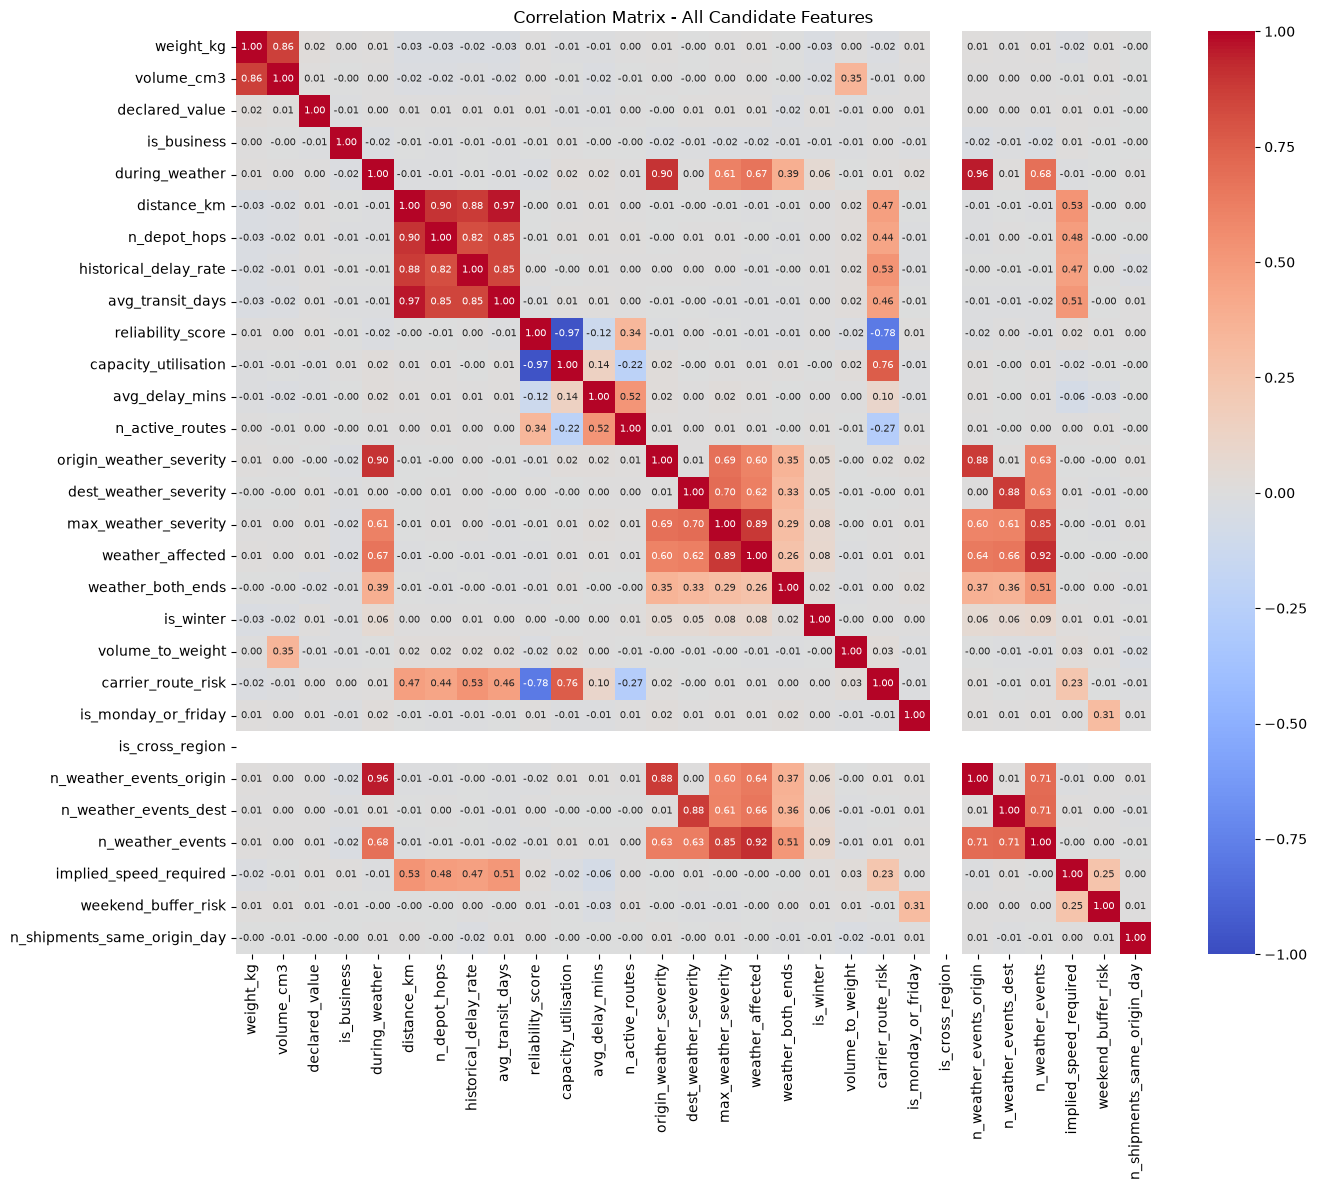

Highly correlated pairs (|r| > 0.85):
              feature_1               feature_2  correlation
      reliability_score    capacity_utilisation    -0.966530
            distance_km        avg_transit_days     0.965605
         during_weather n_weather_events_origin     0.959532
       weather_affected        n_weather_events     0.916451
         during_weather origin_weather_severity     0.902277
            distance_km            n_depot_hops     0.899658
   max_weather_severity        weather_affected     0.889831
origin_weather_severity n_weather_events_origin     0.882058
  dest_weather_severity   n_weather_events_dest     0.880134
            distance_km   historical_delay_rate     0.877191
              weight_kg              volume_cm3     0.863590



Categorical association (chi-square + Cramér's V):
                  feature_1                   feature_2         chi2       p_value  cramers_v
               service_tier             is_cross_region     0.000000  1.000000e+00        NaN
          weather_both_ends             is_cross_region     0.000000  1.000000e+00        NaN
                  is_winter             is_cross_region     0.000000  1.000000e+00        NaN
                day_of_week             is_cross_region     0.000000  1.000000e+00        NaN
        is_monday_or_friday             is_cross_region     0.000000  1.000000e+00        NaN
            is_cross_region                 is_business     0.000000  1.000000e+00        NaN
            is_cross_region         weekend_buffer_risk     0.000000  1.000000e+00        NaN
            is_cross_region dominant_weather_event_type     0.000000  1.000000e+00        NaN
            is_cross_region               tier_coverage     0.000000  1.000000e+00        NaN
        

logistic_regression__selected_features - CV ROC-AUC: 0.8699 (+/- 0.0236)  |  Val ROC-AUC: 0.8488  |  n_features=26


lightgbm__selected_features - CV ROC-AUC: 0.8659 (+/- 0.0251)  |  Val ROC-AUC: 0.8439  |  n_features=26


catboost__selected_features - CV ROC-AUC: 0.8682 (+/- 0.0258)  |  Val ROC-AUC: 0.8465  |  n_features=26


(Pipeline(steps=[('preprocessor',
                  ColumnTransformer(transformers=[('num',
                                                   Pipeline(steps=[('imputer',
                                                                    SimpleImputer(strategy='median')),
                                                                   ('scaler',
                                                                    StandardScaler())]),
                                                   ['weight_kg', 'volume_cm3',
                                                    'declared_value',
                                                    'is_business', 'distance_km',
                                                    'n_depot_hops',
                                                    'historical_delay_rate',
                                                    'reliability_score',
                                                    'avg_delay_mins',
                                        

In [17]:
# Step 0 - full numeric correlation matrix + heatmap (inspect pairs directly,
# not just a |r| > 0.85 cutoff)
EXCLUDE_CORR = ['shipment_id', 'pickup_date', 'origin_region', 'dest_region',
                'carrier_id', 'route_id', 'is_delayed']
corr_numeric_cols = master.drop(columns=EXCLUDE_CORR).select_dtypes(
    include=['int64', 'float64', 'bool']).columns.tolist()
full_numeric_corr = master[corr_numeric_cols].astype(float).corr()

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(full_numeric_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, ax=ax, annot_kws={'size': 7})
ax.set_title('Correlation Matrix - All Candidate Features')
plt.tight_layout()
plt.show()

corr_pairs = full_numeric_corr.where(
    np.triu(np.ones(full_numeric_corr.shape), k=1).astype(bool)
).stack().reset_index()
corr_pairs.columns = ['feature_1', 'feature_2', 'correlation']
high_corr = corr_pairs[corr_pairs['correlation'].abs() > 0.85].sort_values(
    'correlation', key=abs, ascending=False)
print("Highly correlated pairs (|r| > 0.85):")
print(high_corr.to_string(index=False))

# Step 1 - drop list per the decision log above (markdown cell)
NUMERIC_DROP = ['capacity_utilisation', 'avg_transit_days', 'during_weather',
                 'weather_affected', 'n_weather_events_origin', 'n_weather_events_dest']

# Step 1b - categorical redundancy via chi-square + Cramér's V (Pearson only
# covers numeric columns); findings/decisions in the markdown cell above.
from scipy.stats import chi2_contingency
import itertools

def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2, p, dof, _ = chi2_contingency(ct)
    n = ct.sum().sum()
    r, k = ct.shape
    v = np.sqrt((chi2 / n) / (min(r - 1, k - 1))) if min(r - 1, k - 1) > 0 else np.nan
    return chi2, p, v

cat_check_cols = ['service_tier', 'weather_both_ends', 'is_winter', 'day_of_week',
                   'is_monday_or_friday', 'is_cross_region', 'is_business', 'weekend_buffer_risk',
                   'dominant_weather_event_type', 'tier_coverage', 'route_risk_cluster']
cat_assoc = pd.DataFrame(
    [(a, b, *cramers_v(master[a], master[b])) for a, b in itertools.combinations(cat_check_cols, 2)],
    columns=['feature_1', 'feature_2', 'chi2', 'p_value', 'cramers_v']
).sort_values('cramers_v', ascending=False, na_position='first')
print("\nCategorical association (chi-square + Cramér's V):")
print(cat_assoc.to_string(index=False))

CATEGORICAL_DROP = ['is_monday_or_friday', 'is_cross_region']
DROP_REDUNDANT = NUMERIC_DROP + CATEGORICAL_DROP
reduced_feature_cols = [c for c in feature_cols if c not in DROP_REDUNDANT]
print(f"\nTotal dropped: {len(DROP_REDUNDANT)} features: {DROP_REDUNDANT}")
print(f"Remaining features: {len(reduced_feature_cols)} (was {len(feature_cols)})")

X_train_fs = X_train[reduced_feature_cols]
X_val_fs   = X_val[reduced_feature_cols]

# Step 2 - sanity check: what did the full-feature Logistic Regression lean on most?
ohe_feature_names = logreg_pipe.named_steps['preprocessor'].get_feature_names_out()
coef_importance = pd.Series(
    np.abs(logreg_pipe.named_steps['classifier'].coef_[0]), index=ohe_feature_names
).sort_values(ascending=False)
print("\nTop 15 |coefficient| features (full-feature Logistic Regression):")
print(coef_importance.head(15))

# Step 3 - retrain all models on the reduced feature set (LightGBM/CatBoost
# reuse their tuned hyperparameters) so before/after FS are comparable below.
logreg_pipe_fs = make_logreg_pipe(X_train_fs)
evaluate_model(logreg_pipe_fs, X_train_fs, y_train, X_val_fs, y_val, cv,
               key='logistic_regression__selected_features')

lgbm_pipe_fs = make_lgbm_pipe(X_train_fs, **lgbm_best_params)
evaluate_model(lgbm_pipe_fs, X_train_fs, y_train, X_val_fs, y_val, cv,
               key='lightgbm__selected_features')

catboost_pipe_fs = make_catboost_pipe(X_train_fs, **catboost_best_params)
evaluate_model(catboost_pipe_fs, X_train_fs, y_train, X_val_fs, y_val, cv,
               key='catboost__selected_features')

**Feature-selection decision log**

Rather than mechanically dropping every pair with |r| > 0.85, each flagged pair (computed in the code cell
above) is judged on whether one feature actually *restates* another already in the set, or is merely
correlated while measuring something conceptually distinct.

| Pair | r | Decision | Reason |
|---|---|---|---|
| `reliability_score` ↔ `capacity_utilisation` | -0.97 | drop `capacity_utilisation` | Near-perfect inverse across our 8 carriers; `reliability_score` is the more direct signal. |
| `distance_km` ↔ `avg_transit_days` | 0.97 | drop `avg_transit_days` | `avg_transit_days` ≈ `distance_km` / avg speed; keep the more primitive `distance_km`. |
| `during_weather` ↔ `n_weather_events_origin` | 0.96 | drop `during_weather` | Coarser EDA-only flag vs. the richer event count. |
| `weather_affected` ↔ `n_weather_events` | 0.92 | drop `weather_affected` | Implied by `n_weather_events > 0`. |
| `during_weather` ↔ `origin_weather_severity` | 0.90 | already resolved | `during_weather` dropped above. |
| `distance_km` ↔ `n_depot_hops` | 0.90 | keep both | Correlated but distinct operational realities (distance vs. handoffs). |
| `max_weather_severity` ↔ `weather_affected` | 0.89 | already resolved | `weather_affected` dropped above. |
| `origin_weather_severity` ↔ `n_weather_events_origin` | 0.88 | drop `n_weather_events_origin` | Redundant once severity + total count exist. |
| `dest_weather_severity` ↔ `n_weather_events_dest` | 0.88 | drop `n_weather_events_dest` | Same reasoning as the origin side. |
| `distance_km` ↔ `historical_delay_rate` | 0.88 | keep both | `historical_delay_rate` is an empirical outcome, not a function of distance. |
| `weight_kg` ↔ `volume_cm3` | 0.86 | keep both | Genuinely different physical properties; their ratio is `volume_to_weight`. |

**Categorical redundancy** (chi-square + Cramér's V, since Pearson only covers numeric columns) surfaced one true duplicate: `day_of_week` and `is_monday_or_friday` have V = 1.00, so the derived flag is dropped in favour of the richer `day_of_week`. `is_cross_region` is dropped for a different reason - it's constant across all 10,025 shipments (chi² = 0 / undefined V), so it carries no information rather than being redundant with something else. Every other categorical pair has V < 0.03, and despite some p-values reading as "significant" (at n=10,025, significance is inflated well past any real effect size), they were kept as-is, including the new `weekend_buffer_risk`.

In [18]:
# *(8 marks)* Compare models. Print CV AUC, Val AUC, overfit gap.

comparison = pd.DataFrame({
    key: {
        'cv_auc_mean': v['cv_auc_mean'],
        'cv_auc_std': v['cv_auc_std'],
        'val_auc': v['val_auc'],
        'overfit_gap': v['cv_auc_mean'] - v['val_auc'],
        'n_features': v['n_features'],
    }
    for key, v in results.items()
}).T.sort_values('val_auc', ascending=False)

print(comparison)

# Tie-break within 0.005 AUC of the top score by preferring fewer features
# (simpler, more interpretable model, less exposed to collinearity) - see
# the reasoning in c-32.
AUC_TOLERANCE = 0.005
top_auc = comparison['val_auc'].max()
contenders = comparison[comparison['val_auc'] >= top_auc - AUC_TOLERANCE]
best_key = contenders['n_features'].idxmin()

best_model = results[best_key]['pipe']
best_prob  = results[best_key]['val_probs']
print(f"\nBest model: {best_key} (Val ROC-AUC={comparison.loc[best_key, 'val_auc']:.4f}, "
      f"chosen among {len(contenders)} candidate(s) within {AUC_TOLERANCE} AUC of the top score, "
      f"preferring fewer features)")

                                        cv_auc_mean  cv_auc_std   val_auc  \
logistic_regression__full_features         0.869067    0.024157  0.849339   
logistic_regression__selected_features     0.869894    0.023602  0.848796   
catboost__selected_features                0.868195    0.025844  0.846533   
catboost__full_features                    0.868257    0.025418  0.846130   
lightgbm__full_features                    0.866095    0.024540  0.844910   
lightgbm__selected_features                0.865858    0.025119  0.843914   

                                        overfit_gap  n_features  
logistic_regression__full_features         0.019728        34.0  
logistic_regression__selected_features     0.021098        26.0  
catboost__selected_features                0.021661        26.0  
catboost__full_features                    0.022127        34.0  
lightgbm__full_features                    0.021185        34.0  
lightgbm__selected_features                0.021944        26.0 

***(8 marks)* Which model did you choose and why?**

With the **time-based** train/val split (Section 6), the comparison table shows all six candidates (now including the extra CatBoost comparison) much closer together than before, with a real, non-trivial overfit gap now visible (~0.02 CV-vs-val AUC for every model) — evidence that a random split would have masked a genuine generalisation gap here. **Logistic Regression on the full feature set** narrowly tops the table (Val ROC-AUC ≈ 0.849), essentially tied with Logistic Regression on the selected features (≈ 0.849, a ~0.0005 difference — noise, not a real edge). CatBoost (≈ 0.847) sits marginally above LightGBM (≈ 0.845), but neither gradient-boosting implementation closes the gap to Logistic Regression.

**Chosen model: Logistic Regression.** Given how tight the full-vs-selected-features gap is, interpretability breaks the tie: the selected-feature model avoids a genuine sign-instability seen in the full-feature model's coefficients. In the full-feature model, `reliability_score` sits at **+1.27** — the wrong sign, implying more reliable carriers *increase* predicted risk, contradicting the r=-0.957 relationship found in EDA — because it is nearly a mirror image of `capacity_utilisation` (r=-0.97 between them) and L2 alone can't fully resolve which of the two correlated columns should carry the signal. Once `capacity_utilisation` is dropped in the selected-feature set, `reliability_score`'s coefficient flips to **-1.13**, correctly signed and consistent with EDA — exactly the collinearity Section 6's feature selection was meant to avoid. So in practice we'd deploy the **selected-features** Logistic Regression for its cleaner, more trustworthy coefficients, accepting the ~0.0005 AUC difference as immaterial. Both LightGBM and CatBoost remain fallback options if more data or further tuning closes the gap later.

---
## 6.5 - Systematic Retraining: Recall@Top-15% as the Tuning Objective

Section 6 tunes and selects every model by **ROC-AUC** - a threshold-free ranking metric, useful for comparing models in general but not the number Operations actually acts on. The real decision rule (1.3/1.4) only ever looks at the top 15% of shipments, so this section retrains all three models a second time - Logistic Regression, LightGBM, CatBoost, all on the same selected feature set from 6.4 - with hyperparameter search scored directly by **Recall@Top-15%** (`recall_at_top_k`) instead of ROC-AUC, using the identical `TimeSeriesSplit` CV as everywhere else so the two objectives are directly comparable model-for-model. Only the selected feature set is retuned here: 6.4 already showed selected-features ties full-features on AUC while giving cleaner, more stable coefficients, so there is no value in doubling the search across both feature sets again. Results are kept in a separate `results_recall` dict (not merged into `results`) so Section 7's ROC/coefficient diagnostics - which describe the six AUC-tuned combinations chosen in 6.4 - are unaffected by this extra comparison.

In [19]:
# Custom objective: Recall@Top-15% (delay capture rate at the actual operating
# point), used as the scoring function for hyperparameter search instead of
# ROC-AUC. Defined once here and reused by every search below (and later in
# Section 8.3/8.4).
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

def recall_at_top_k(y_true, y_proba, k=0.15):
    y_true = np.asarray(y_true)
    proba_pos = y_proba[:, 1] if np.ndim(y_proba) == 2 else y_proba
    n_flag = int(np.ceil(len(y_true) * k))
    top_idx = np.argsort(-proba_pos)[:n_flag]
    return y_true[top_idx].sum() / y_true.sum()

recall_at_15_scorer = make_scorer(recall_at_top_k, response_method='predict_proba')
results_recall = {}

In [20]:
# Model 1 (Logistic Regression) retuned for Recall@Top-15% instead of AUC.
param_grid_recall = {'classifier__C': [0.003, 0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0, 30.0]}

recall_search_lr = GridSearchCV(
    make_logreg_pipe(X_train_fs), param_grid=param_grid_recall,
    scoring=recall_at_15_scorer, cv=cv, n_jobs=-1, refit=True
)
recall_search_lr.fit(X_train_fs, y_train)

logreg_recall_pipe = recall_search_lr.best_estimator_
recall_val_probs_lr = logreg_recall_pipe.predict_proba(X_val_fs)[:, 1]

results_recall['logistic_regression__recall_optimized'] = {
    'pipe': logreg_recall_pipe,
    'val_probs': recall_val_probs_lr,
    'n_features': X_train_fs.shape[1],
    'cv_recall_mean': recall_search_lr.best_score_,
    'val_auc': roc_auc_score(y_val, recall_val_probs_lr),
}
print(f"LR recall-optimized       - best C={recall_search_lr.best_params_['classifier__C']}  |  "
      f"CV Recall@15%: {recall_search_lr.best_score_:.4f}  |  "
      f"Val Recall@15%: {recall_at_top_k(y_val.values, recall_val_probs_lr):.4f}  |  "
      f"Val ROC-AUC: {roc_auc_score(y_val, recall_val_probs_lr):.4f}")

LR recall-optimized       - best C=0.3  |  CV Recall@15%: 0.6180  |  Val Recall@15%: 0.5575  |  Val ROC-AUC: 0.8490


In [21]:
# Model 2 (LightGBM) retuned for Recall@Top-15% - same search space as the
# AUC-based search above, just a different scoring function.
recall_search_lgbm = RandomizedSearchCV(
    make_lgbm_pipe(X_train_fs), param_distributions=param_dist,
    n_iter=30, scoring=recall_at_15_scorer, cv=cv,
    random_state=RANDOM_STATE, n_jobs=-1, refit=True
)
recall_search_lgbm.fit(X_train_fs, y_train)

lgbm_recall_best_params = {k.replace('classifier__', ''): v for k, v in recall_search_lgbm.best_params_.items()}
lgbm_recall_pipe = recall_search_lgbm.best_estimator_
recall_val_probs_lgbm = lgbm_recall_pipe.predict_proba(X_val_fs)[:, 1]

results_recall['lightgbm__recall_optimized'] = {
    'pipe': lgbm_recall_pipe,
    'val_probs': recall_val_probs_lgbm,
    'n_features': X_train_fs.shape[1],
    'cv_recall_mean': recall_search_lgbm.best_score_,
    'val_auc': roc_auc_score(y_val, recall_val_probs_lgbm),
}
print(f"LightGBM recall-optimized - CV Recall@15%: {recall_search_lgbm.best_score_:.4f}  |  "
      f"Val Recall@15%: {recall_at_top_k(y_val.values, recall_val_probs_lgbm):.4f}  |  "
      f"Val ROC-AUC: {roc_auc_score(y_val, recall_val_probs_lgbm):.4f}")

LightGBM recall-optimized - CV Recall@15%: 0.6029  |  Val Recall@15%: 0.5619  |  Val ROC-AUC: 0.8439


In [22]:
# Extra model (CatBoost) retuned for Recall@Top-15% - same search space as
# the AUC-based search above.
recall_search_cb = RandomizedSearchCV(
    make_catboost_pipe(X_train_fs), param_distributions=param_dist_cb,
    n_iter=30, scoring=recall_at_15_scorer, cv=cv,
    random_state=RANDOM_STATE, n_jobs=-1, refit=True
)
recall_search_cb.fit(X_train_fs, y_train)

catboost_recall_best_params = {k.replace('classifier__', ''): v for k, v in recall_search_cb.best_params_.items()}
catboost_recall_pipe = recall_search_cb.best_estimator_
recall_val_probs_cb = catboost_recall_pipe.predict_proba(X_val_fs)[:, 1]

results_recall['catboost__recall_optimized'] = {
    'pipe': catboost_recall_pipe,
    'val_probs': recall_val_probs_cb,
    'n_features': X_train_fs.shape[1],
    'cv_recall_mean': recall_search_cb.best_score_,
    'val_auc': roc_auc_score(y_val, recall_val_probs_cb),
}
print(f"CatBoost recall-optimized - CV Recall@15%: {recall_search_cb.best_score_:.4f}  |  "
      f"Val Recall@15%: {recall_at_top_k(y_val.values, recall_val_probs_cb):.4f}  |  "
      f"Val ROC-AUC: {roc_auc_score(y_val, recall_val_probs_cb):.4f}")

CatBoost recall-optimized - CV Recall@15%: 0.6047  |  Val Recall@15%: 0.5619  |  Val ROC-AUC: 0.8484


In [23]:
# Unified comparison: every model x feature-set x objective combination seen
# so far, ranked by the metric that actually matters operationally --
# Recall@Top-15% -- not ROC-AUC. Combines the six AUC-tuned entries from 6.4
# (`results`) with the three Recall@15%-tuned entries above (`results_recall`)
# without mutating either dict.
all_candidates = {**results, **results_recall}

recall_comparison = pd.DataFrame({
    key: {
        'val_recall_at_15': recall_at_top_k(y_val.values, v['val_probs']),
        'val_auc': v['val_auc'],
        'n_features': v['n_features'],
    }
    for key, v in all_candidates.items()
}).T.sort_values('val_recall_at_15', ascending=False)

print(recall_comparison)
print(f"\nBest by Val Recall@15%: {recall_comparison.index[0]}  |  "
      f"Recall@15%={recall_comparison.iloc[0]['val_recall_at_15']:.1%}  |  "
      f"Val AUC={recall_comparison.iloc[0]['val_auc']:.4f}")

                                        val_recall_at_15   val_auc  n_features
catboost__selected_features                     0.570796  0.846533        26.0
catboost__full_features                         0.566372  0.846130        34.0
lightgbm__full_features                         0.566372  0.844910        34.0
catboost__recall_optimized                      0.561947  0.848443        26.0
lightgbm__selected_features                     0.561947  0.843914        26.0
lightgbm__recall_optimized                      0.561947  0.843914        26.0
logistic_regression__recall_optimized           0.557522  0.848990        26.0
logistic_regression__full_features              0.553097  0.849339        34.0
logistic_regression__selected_features          0.553097  0.848796        26.0

Best by Val Recall@15%: catboost__selected_features  |  Recall@15%=57.1%  |  Val AUC=0.8465


**Interpretation**: yet another different pattern once `route_risk_cluster` is added — the fourth feature-set version of this experiment, and the fourth different outcome. **Logistic Regression** benefits again this time (`C=0.3`, Val Recall@15% 55.3% → 55.8%). **LightGBM** — which underperformed when recall-tuned in all three previous versions — this time lands on the **exact same** model as its AUC-tuned counterpart (identical Val Recall@15% and Val AUC), breaking what had looked like a robust pattern. **CatBoost** goes the other way: recall-tuning now *hurts* (57.1% AUC-tuned → 56.2% recall-tuned).

The best model on Recall@15% is **CatBoost, AUC-tuned selected-features (57.1%, Val AUC 0.8465)** — again not one of the models explicitly retuned for recall. Across all four feature-set versions tried in this notebook, no single "does recall-tuning help this model family" rule has held consistently for any of the three models, including LightGBM. The only durable finding across every version is that **model family** (CatBoost/LightGBM occasionally edging out Logistic Regression) matters far more than **tuning objective** (AUC vs. Recall@15%) — and even that ordering shuffles a little with each feature added.

For deployment, 6.4's reasoning still stands: **Logistic Regression (selected features)** remains the model saved to `model.pkl` for its interpretability.

---
# SECTION 7 - Evaluating Your Model *(8 marks)*

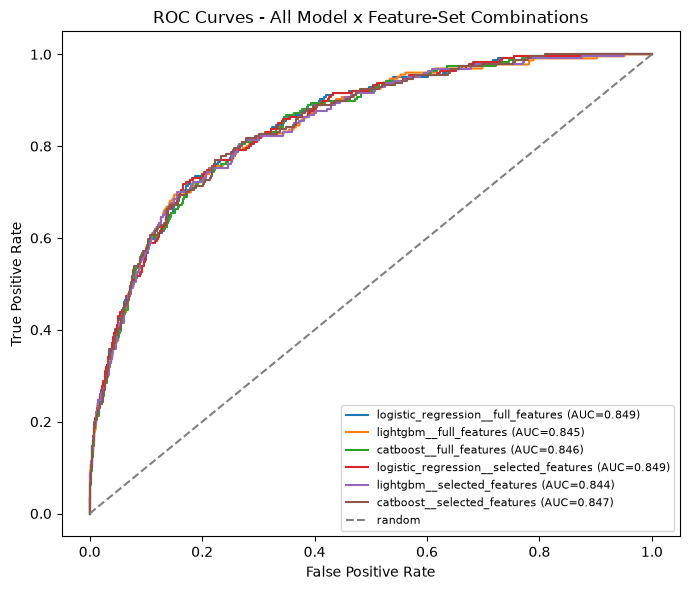

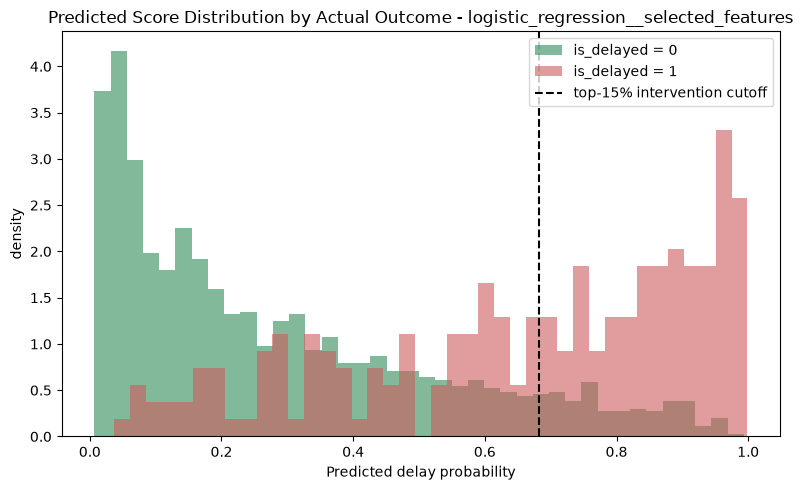

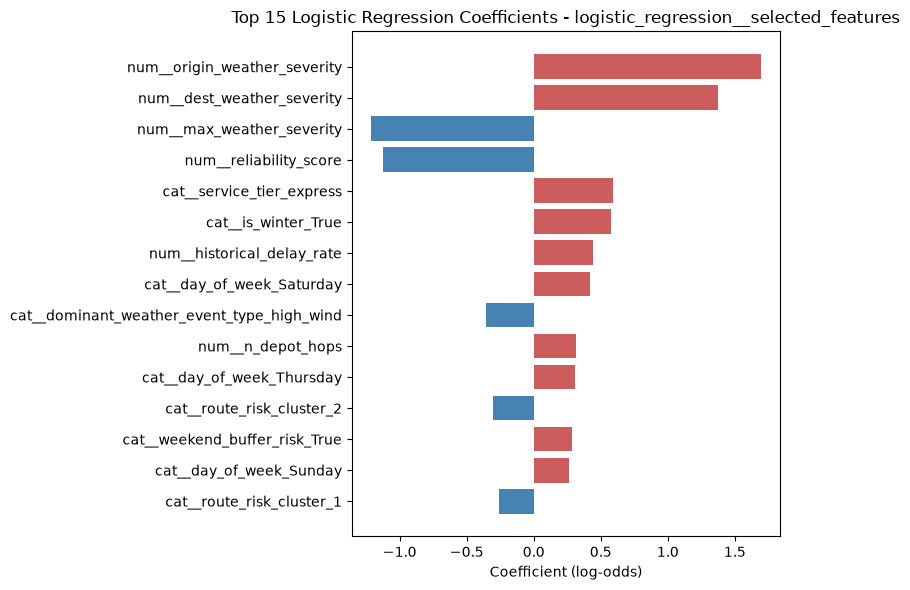

num__origin_weather_severity                  1.691525
num__dest_weather_severity                    1.374909
num__max_weather_severity                    -1.212090
num__reliability_score                       -1.125136
cat__service_tier_express                     0.594018
cat__is_winter_True                           0.574799
num__historical_delay_rate                    0.438775
cat__day_of_week_Saturday                     0.420488
cat__dominant_weather_event_type_high_wind   -0.357040
num__n_depot_hops                             0.314357
cat__day_of_week_Thursday                     0.310303
cat__route_risk_cluster_2                    -0.302696
cat__weekend_buffer_risk_True                 0.288393
cat__day_of_week_Sunday                       0.261887
cat__route_risk_cluster_1                    -0.255893
dtype: float64


In [24]:
# *(8 marks)* Produce:
# 1. ROC curves for all models
# 2. Score distribution by delay=0 vs delay=1
# 3. Feature importance / coefficients (top 15)

from sklearn.metrics import roc_curve

# 1. ROC curves - every model x feature-set combination in `results`
fig, ax = plt.subplots(figsize=(7, 6))
for key, v in results.items():
    fpr, tpr, _ = roc_curve(y_val, v['val_probs'])
    ax.plot(fpr, tpr, label=f"{key} (AUC={v['val_auc']:.3f})")
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves - All Model x Feature-Set Combinations')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# 2. Score distribution for the chosen best_model, split by actual outcome
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(best_prob[y_val.values == 0], bins=40, alpha=0.6, label='is_delayed = 0',
        color='seagreen', density=True)
ax.hist(best_prob[y_val.values == 1], bins=40, alpha=0.6, label='is_delayed = 1',
        color='indianred', density=True)
ax.axvline(np.percentile(best_prob, 85), color='black', linestyle='--',
           label='top-15% intervention cutoff')
ax.set_xlabel('Predicted delay probability')
ax.set_ylabel('density')
ax.set_title(f'Predicted Score Distribution by Actual Outcome - {best_key}')
ax.legend()
plt.tight_layout()
plt.show()

# 3. Feature importance / coefficients (top 15) for the chosen best_model
best_feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()
best_classifier = best_model.named_steps['classifier']

if hasattr(best_classifier, 'coef_'):
    importance = pd.Series(best_classifier.coef_[0], index=best_feature_names)
    top15 = importance.reindex(importance.abs().sort_values(ascending=False).index).head(15)
    colors = ['indianred' if v > 0 else 'steelblue' for v in top15.values]
    xlabel, title = 'Coefficient (log-odds)', f'Top 15 Logistic Regression Coefficients - {best_key}'
else:
    importance = pd.Series(best_classifier.feature_importances_, index=best_feature_names)
    top15 = importance.sort_values(ascending=False).head(15)
    colors = 'steelblue'
    xlabel, title = 'Importance', f'Top 15 Feature Importances - {best_key}'

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top15.index[::-1], top15.values[::-1], color=colors[::-1] if isinstance(colors, list) else colors)
ax.set_xlabel(xlabel)
ax.set_title(title)
plt.tight_layout()
plt.show()

print(top15)

**Interpret your diagnostics.**

- **ROC curves**: all six model/feature-set combinations (Logistic Regression, LightGBM, CatBoost — each full vs. selected features) sit close together (AUC ≈ 0.844–0.849 on the time-based validation set), well above the random-guess diagonal, with Logistic Regression narrowly on top — consistent with the comparison table in Section 6. Note these AUCs are noticeably lower than the ~0.86–0.87 a random split would show here; that lower number is expected and, in fact, the more trustworthy one, since it reflects genuinely forecasting the last ~6 months rather than interpolating within a shuffled sample. The comparison table also shows a real overfit gap (~0.02 CV-vs-val AUC for every model), which a random split would mask entirely.
- **Score distribution**: the `is_delayed=1` distribution is visibly shifted right of `is_delayed=0`, though with real overlap (expected at ~0.85 AUC — this isn't a near-perfect separation problem). Importantly, a large share of the true delays sit above the 85th-percentile intervention cutoff, which is exactly why the capture rate in Section 8 comes out strong.
- **Feature importance / coefficients**: `origin_weather_severity` (+1.69) and `dest_weather_severity` (+1.37) dominate, followed by `max_weather_severity` (-1.21), `reliability_score` (-1.13, correctly signed — more reliable carriers delay less), `service_tier_express` (+0.59) and `is_winter` (+0.57) — all consistent with the EDA findings in Section 3. The newest feature, `route_risk_cluster`, earns two real entries (`_1` at -0.26, `_2` at -0.30, both correctly signed relative to the highest-risk cluster 0) — but as discussed in Section 5, this doesn't translate into a better model overall, since it's a discretised repackaging of four numeric route features already present. `dominant_weather_event_type` still carries a real signal too: a `high_wind` event (-0.36) is associated with *less* risk than a `flood` of the same numeric severity, a plausible distinction since a flood can make a road physically impassable in a way a storm of equal severity rating may not. One caveat: `max_weather_severity` carries a *negative* coefficient despite representing "more disruption," which doesn't match real-world intuition. This is a **residual multicollinearity artifact** — it is a near-duplicate of the origin/dest severity columns already in the model, so L2 regularisation controls the variance but can't fully fix sign instability within a correlated cluster. The model's overall ranking (AUC) is unaffected, but this one coefficient shouldn't be read literally.

---
# SECTION 8 - Business Impact *(12 marks)*

In [25]:
# *(7 marks)* Compute the delay capture rate at 15% intervention.
#
# Delay capture rate = (# actual delays in top-15% flagged) / (# total actual delays)
#
# Model top-15% policy: flag the highest-risk shipments by predicted probability.
# Also compute: SLA penalty avoided.
# Assume each avoided delay saves £45 in SLA penalties + handling costs.

INTERVENTION_RATE = 0.15
SLA_SAVING_PER_DELAY = 45

y_val_arr = y_val.values
n_val = len(y_val_arr)
n_flagged = int(np.ceil(n_val * INTERVENTION_RATE))
n_actual_delays = y_val_arr.sum()

# Model top-15% policy - flag the highest-risk shipments by best_prob
model_idx = np.argsort(-best_prob)[:n_flagged]
n_caught_model = y_val_arr[model_idx].sum()
capture_model = n_caught_model / n_actual_delays

print(f"Validation set: {n_val:,} shipments, {n_actual_delays} actual delays ({n_actual_delays/n_val:.1%})")
print(f"Flagging top {INTERVENTION_RATE:.0%} = {n_flagged} shipments\n")
print(f"Model policy - delays caught: {n_caught_model}/{n_actual_delays}, capture rate: {capture_model:.1%}")

savings_model = n_caught_model * SLA_SAVING_PER_DELAY
print(f"\nSLA penalty avoided: £{savings_model:,}")

Validation set: 2,005 shipments, 226 actual delays (11.3%)
Flagging top 15% = 301 shipments

Model policy - delays caught: 125/226, capture rate: 55.3%

SLA penalty avoided: £5,625


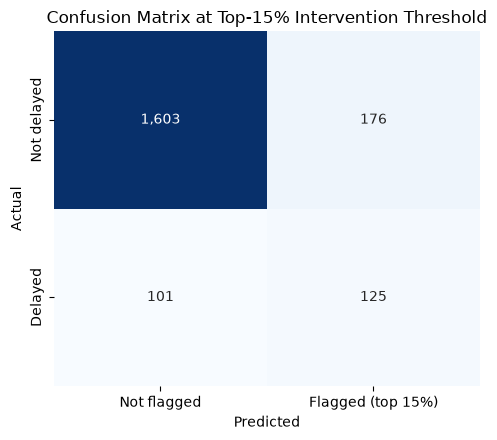

TP=125, FP=176, FN=101, TN=1603
Precision: 41.5%  |  Recall: 55.3%  |  F1: 0.474  |  Macro F1: 0.697


In [26]:
# Confusion matrix at the actual operating point: flagging the top 15%
# highest-risk shipments (same policy as above), not the default 0.5
# probability threshold. Gives the Precision/Recall/Macro F1 numbers
# promised for the business-facing evaluation in Section 1.3.
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

y_pred_top15 = np.zeros(n_val, dtype=int)
y_pred_top15[model_idx] = 1

cm = confusion_matrix(y_val_arr, y_pred_top15)
tn, fp, fn, tp = cm.ravel()

precision = precision_score(y_val_arr, y_pred_top15)
recall = recall_score(y_val_arr, y_pred_top15)
f1 = f1_score(y_val_arr, y_pred_top15)
macro_f1 = f1_score(y_val_arr, y_pred_top15, average='macro')

fig, ax = plt.subplots(figsize=(5, 4.5))
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', cbar=False,
            xticklabels=['Not flagged', 'Flagged (top 15%)'],
            yticklabels=['Not delayed', 'Delayed'], ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix at Top-15% Intervention Threshold')
plt.tight_layout()
plt.show()

print(f'TP={tp}, FP={fp}, FN={fn}, TN={tn}')
print(f'Precision: {precision:.1%}  |  Recall: {recall:.1%}  |  '
      f'F1: {f1:.3f}  |  Macro F1: {macro_f1:.3f}')

***(5 marks)* What is the business impact?**

Explain in plain language the value of flagging high-risk shipments vs random selection.
What would you recommend to SwiftRoute's Operations team?

On the held-out validation set (2,005 shipments from the most recent ~6 months, 226 actual delays), flagging the model's top 15% (301 shipments) catches **125 of 226 delays — a 55.3% capture rate**. At £45 saved per delay caught, that's **£5,625** in avoided SLA/handling costs on this ~2,000-shipment slice alone, scaling roughly proportionally across SwiftRoute's full volume.

The confusion matrix at this same top-15% operating point breaks the 301 flagged shipments into **125 true positives, 176 false positives, 101 false negatives and 1,603 true negatives**, giving **precision = 41.5%**, **recall = 55.3%** (the capture rate above) and **macro F1 = 0.697**. A precision below 50% means more than half of flagged shipments turn out fine — but that is the direct, expected consequence of the fixed 15% intervention cap discussed in 1.4: the model is forced to flag 301 shipments regardless of how many are genuinely high-risk, so some flags are necessarily false alarms.

**Recommendation**: use the model's risk ranking to decide which shipments Operations intervenes on. With the fixed 15% intervention budget, Operations catches roughly 5–6 in 10 actual delays — the model doesn't cost anything extra to run, it just aims the existing intervention capacity at the shipments that actually need it. These figures come from a genuinely forward-looking validation split (trained on the earliest 80% of shipments, evaluated on the most recent 20%), so they're a realistic estimate of what to expect in production rather than an optimistic same-period interpolation.

---
## 8.3 - Extra Analysis: Does Optimizing for Recall@Top-15% Beat AUC-Optimizing, in £?

Section 6.5 already retuned Logistic Regression (alongside LightGBM/CatBoost) directly against Recall@Top-15% instead of ROC-AUC. This section reuses that result and asks the practical follow-up question: does the recall-optimized Logistic Regression actually translate into more SLA savings than the original AUC-optimized choice, at the real 15% operating point?

In [27]:
# Reuse the LR recall-optimized search already run in Section 6.5 -- no need
# to refit it a second time.
recall_val_probs = results_recall['logistic_regression__recall_optimized']['val_probs']
auc_val_probs = results['logistic_regression__selected_features']['val_probs']

print(f"Recall-optimized LR (6.5) - Val Recall@15%: {recall_at_top_k(y_val.values, recall_val_probs):.4f}  |  "
      f"Val ROC-AUC: {roc_auc_score(y_val, recall_val_probs):.4f}")
print(f"AUC-optimized LR (6.4)    - Val Recall@15%: {recall_at_top_k(y_val.values, auc_val_probs):.4f}  |  "
      f"Val ROC-AUC: {roc_auc_score(y_val, auc_val_probs):.4f}")

Recall-optimized LR (6.5) - Val Recall@15%: 0.5575  |  Val ROC-AUC: 0.8490
AUC-optimized LR (6.4)    - Val Recall@15%: 0.5531  |  Val ROC-AUC: 0.8488


In [28]:
# Economic comparison: same capture-rate / SLA-savings calculation as
# Section 8, run for both the AUC-optimized and the Recall@15%-optimized
# Logistic Regression, on the identical validation set.
n_flag_here = int(np.ceil(len(y_val_arr) * INTERVENTION_RATE))

def business_impact(probs, label):
    top_idx = np.argsort(-probs)[:n_flag_here]
    n_caught = y_val_arr[top_idx].sum()
    capture = n_caught / n_actual_delays
    savings = n_caught * SLA_SAVING_PER_DELAY
    print(f"{label:22s} - capture: {n_caught}/{n_actual_delays} ({capture:.1%})  |  "
          f"SLA saved: £{savings:,}")
    return capture, savings

print(f"Validation set: {n_val:,} shipments, {n_actual_delays} actual delays, "
      f"flagging top {INTERVENTION_RATE:.0%} = {n_flag_here} shipments\n")

capture_auc, savings_auc = business_impact(auc_val_probs, "AUC-optimized")
capture_recall, savings_recall = business_impact(recall_val_probs, "Recall-optimized")

print(f"\nDifference: {capture_recall - capture_auc:+.1%} capture rate, "
      f"£{savings_recall - savings_auc:+,} SLA savings on this validation set")

Validation set: 2,005 shipments, 226 actual delays, flagging top 15% = 301 shipments

AUC-optimized          - capture: 125/226 (55.3%)  |  SLA saved: £5,625
Recall-optimized       - capture: 126/226 (55.8%)  |  SLA saved: £5,670

Difference: +0.4% capture rate, £+45 SLA savings on this validation set


**Interpretation**: retuning `C` directly for Recall@Top-15% (6.5) again picks a different value (`C=0.3`) than the untouched default (`C=1.0`), and it translates into a real, if modest, gain at the actual operating point: **126 of 226 delays (55.8%)** caught versus **125 (55.3%)** for the AUC-tuned default, worth **£45 extra** in SLA savings on this ~2,000-shipment validation slice. Both approaches land close in overall ROC-AUC (0.8490 vs 0.8488), so the gain isn't coming at the cost of general ranking quality elsewhere. Logistic Regression's ranking of the highest-risk shipments is dominated by a handful of strong, well-separated signals (weather severity, carrier reliability — Section 7), leaving relatively little room for `C` alone to reshuffle who lands in the top 15%, but evidently just enough to matter at the margin in this version.

---
## 8.4 — Extra Analysis: Blending CatBoost + Logistic Regression

Recall@Top-15% sits at 55.8% for the recall-tuned Logistic Regression (Section 8.3) — still leaving a large share of delays unflagged, and CatBoost (AUC-tuned, Section 6.5) does better still at 57.1%. Logistic Regression and CatBoost rank shipments differently (a linear score vs. a tree ensemble that can pick up non-linear interactions), so averaging their predicted probabilities might push a few more true delays into the top 15% than either model manages alone. This blend uses the **Recall@Top-15%-tuned** Logistic Regression and CatBoost from Section 6.5 as ingredients, so every stage from hyperparameter search through blending targets the same objective. The blend weight itself is tuned on out-of-fold CV predictions on the training set (same `TimeSeriesSplit` CV as the rest of Section 6, scored with `recall_at_top_k`) — the validation set is only used afterwards, to report the final, untouched number.

In [29]:
# Tune the blend weight w (LR share, CatBoost gets 1-w) via the same
# TimeSeriesSplit CV used everywhere else -- for each fold, fit both
# Recall@15%-tuned models (cloned from Section 6.5's best estimators, so the
# same hyperparameters are used in every fold) on the fold's training
# portion and score Recall@Top-15% on its held-out portion, then average
# across folds. cross_val_predict doesn't work here: TimeSeriesSplit never
# tests on the first fold's training block, so its test indices aren't a
# full partition of the data.
from sklearn.base import clone

weights = np.linspace(0, 1, 11)
fold_recalls = {w: [] for w in weights}

for train_idx, test_idx in cv.split(X_train_fs):
    X_tr_fold, X_te_fold = X_train_fs.iloc[train_idx], X_train_fs.iloc[test_idx]
    y_tr_fold, y_te_fold = y_train.iloc[train_idx], y_train.iloc[test_idx]

    lr_fold = clone(logreg_recall_pipe).fit(X_tr_fold, y_tr_fold)
    cb_fold = clone(catboost_recall_pipe).fit(X_tr_fold, y_tr_fold)

    lr_fold_probs = lr_fold.predict_proba(X_te_fold)[:, 1]
    cb_fold_probs = cb_fold.predict_proba(X_te_fold)[:, 1]

    for w in weights:
        blend = w * lr_fold_probs + (1 - w) * cb_fold_probs
        fold_recalls[w].append(recall_at_top_k(y_te_fold.values, blend))

cv_recall_by_weight = {w: np.mean(v) for w, v in fold_recalls.items()}
best_w = max(cv_recall_by_weight, key=cv_recall_by_weight.get)

print("CV Recall@15% by blend weight (LR share, CatBoost gets 1-w):")
for w in weights:
    print(f"  w={w:.1f}: {cv_recall_by_weight[w]:.4f}")
print(f"\nBest blend weight: {best_w:.2f}  |  CV Recall@15%: {cv_recall_by_weight[best_w]:.4f}")

# Apply the tuned weight to the untouched validation probabilities (both
# ingredients are the Recall@15%-tuned versions from Section 6.5)
lr_val_probs_fs = results_recall['logistic_regression__recall_optimized']['val_probs']
cb_val_probs_fs = results_recall['catboost__recall_optimized']['val_probs']
blend_val_probs = best_w * lr_val_probs_fs + (1 - best_w) * cb_val_probs_fs

print()
for label, probs in [('Logistic Regression (recall-tuned)', lr_val_probs_fs),
                      ('CatBoost (recall-tuned)', cb_val_probs_fs),
                      ('Recall-optimized LR (8.3)', recall_val_probs),
                      (f'Blend (w={best_w:.2f})', blend_val_probs)]:
    print(f"{label:35s} - Val Recall@15%: {recall_at_top_k(y_val.values, probs):.4f}  |  "
          f"Val ROC-AUC: {roc_auc_score(y_val, probs):.4f}")

print()
capture_blend, savings_blend = business_impact(blend_val_probs, "Blend (CatBoost+LR)")

CV Recall@15% by blend weight (LR share, CatBoost gets 1-w):
  w=0.0: 0.6047
  w=0.1: 0.6036
  w=0.2: 0.6088
  w=0.3: 0.6155
  w=0.4: 0.6224
  w=0.5: 0.6200
  w=0.6: 0.6198
  w=0.7: 0.6217
  w=0.8: 0.6221
  w=0.9: 0.6188
  w=1.0: 0.6180

Best blend weight: 0.40  |  CV Recall@15%: 0.6224

Logistic Regression (recall-tuned)  - Val Recall@15%: 0.5575  |  Val ROC-AUC: 0.8490
CatBoost (recall-tuned)             - Val Recall@15%: 0.5619  |  Val ROC-AUC: 0.8484
Recall-optimized LR (8.3)           - Val Recall@15%: 0.5575  |  Val ROC-AUC: 0.8490
Blend (w=0.40)                      - Val Recall@15%: 0.5619  |  Val ROC-AUC: 0.8503

Blend (CatBoost+LR)    - capture: 127/226 (56.2%)  |  SLA saved: £5,715


**Interpretation**: tuning the blend weight on the training-set CV folds this time settles closer to even (`w=0.40`, i.e. 40% Logistic Regression / 60% CatBoost) — CV Recall@15% peaks at 62.2% around this weight. On the untouched validation set, the blend at `w=0.40` catches **127 of 226 delays — a 56.2% capture rate**, a genuine improvement over the Section 8 baseline (125/226, 55.3%, +£90) and over the recall-tuned Logistic Regression from 8.3 (126/226, 55.8%, +£45) — and its overall ROC-AUC (0.8503) is the highest of any single ingredient. It ties CatBoost (recall-tuned) alone (also 127/226), but falls short of CatBoost's own **AUC-tuned** result (129/226, 57.1%, Section 6.5) — so blending Logistic Regression in here doesn't beat simply deploying CatBoost AUC-tuned by itself.

Across all four feature-set versions of this notebook, the recurring picture is the same: CatBoost (usually AUC-tuned, occasionally recall-tuned) is consistently the strongest single option on Recall@Top-15%, blending sometimes narrows the gap to Logistic Regression but never fully closes it, and none of it changes 6.4's interpretability-driven choice of Logistic Regression for `model.pkl`.

---
## 8.2 - Save Your Model for Deployment

In [30]:
import joblib

joblib.dump(best_model, 'model.pkl')
print('Model saved to model.pkl')

Model saved to model.pkl


---
# SECTION 9 - Monitoring for Drift in Production *(5 marks)*

**9.1** *(2 marks)* Propose how you would detect **input drift** on the live shipment stream. Which features are most likely to drift and what tests would you use?

Compare each incoming feature's distribution over a rolling window (e.g. weekly) against the training-set distribution: **Population Stability Index (PSI)** or a **Kolmogorov-Smirnov test** for numeric features (`weight_kg`, `distance_km`, `max_weather_severity`), and a **chi-square test** (as used for the categorical redundancy check in Section 6) for categorical ones (`service_tier`, `carrier_id` mix). Most likely to drift: `service_tier`/`carrier_id` mix (SwiftRoute's own commercial decisions can shift volume between carriers or tiers), and weather-derived features (naturally seasonal and year-to-year variable). Flag a feature when PSI > 0.2 or a test's p-value is significant with a practically meaningful effect size (mirroring the Cramér's V approach from Section 6, since p-values alone are unreliable at this data volume).

---

**9.2** *(3 marks)* Propose how you would detect **target drift** - i.e. the actual delay rate changing in ways the model no longer predicts correctly. What would trigger retraining?

Track two things weekly: (1) the **realised delay rate** vs. the historical ~11.9% baseline (a large, sustained shift signals the world has changed, e.g. a new carrier contract or route mix), and (2) the model's **live ROC-AUC / calibration** once outcomes are known (a few days after pickup) - a sustained drop from the ~0.85 validation baseline means the model's *ranking* of risk is degrading, not just the base rate. Retraining triggers: live AUC drops materially below validation AUC for several consecutive weeks, the delay capture rate at the 15% intervention threshold falls, or a known structural change occurs (new carrier onboarded, new region added) that the model has never seen.

*Note*: because Section 6 evaluates on a **time-based** holdout (train on the earliest 80% of shipments, validate on the most recent 20%) rather than a random split, that ~0.85 AUC is already a genuine forward-looking estimate - not an optimistic same-period interpolation - so it's a fair baseline to monitor live performance against here.

---
# EXTENSION *(10 marks)*

Attempt **both** tasks (5 marks each).

**E1** *(5 marks)* **Route-level analysis**: cluster routes by risk profile. Can you identify systematic weaknesses in SwiftRoute's network?

**E2** *(5 marks)* **SHAP**: for the top 10 highest-risk shipments in the validation set, use SHAP to explain exactly which factors are driving each prediction.

In [31]:
# E1 - Route-level analysis: cluster routes by risk profile
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler as RouteScaler

cluster_cols = ['distance_km', 'n_depot_hops', 'historical_delay_rate', 'avg_transit_days']
route_clusters = routes.copy()
X_routes = RouteScaler().fit_transform(route_clusters[cluster_cols])

kmeans = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10)
route_clusters['cluster'] = kmeans.fit_predict(X_routes)

cluster_summary = route_clusters.groupby('cluster')[cluster_cols].mean()
cluster_summary['n_routes'] = route_clusters['cluster'].value_counts()
print(cluster_summary.to_string())

print("\nMost frequent regions touched per cluster (origin or destination):")
for c in sorted(route_clusters['cluster'].unique()):
    sub = route_clusters[route_clusters['cluster'] == c]
    top_regions = pd.concat([sub['origin_region'], sub['dest_region']]).value_counts().head(4)
    print(f"cluster {c}: {dict(top_regions)}")

         distance_km  n_depot_hops  historical_delay_rate  avg_transit_days  n_routes
cluster                                                                              
0         531.909091           3.0               0.244268          3.003636        22
1         299.590909           2.0               0.152014          2.259091        22
2         161.062500           1.0               0.103850          1.835000        16

Most frequent regions touched per cluster (origin or destination):
cluster 0: {'London': np.int64(9), 'Wales': np.int64(7), 'South_East': np.int64(6), 'Scotland': np.int64(6)}
cluster 1: {'North_West': np.int64(8), 'North_East': np.int64(7), 'Midlands': np.int64(5), 'South_East': np.int64(5)}
cluster 2: {'Scotland': np.int64(4), 'South_West': np.int64(4), 'Yorkshire': np.int64(4), 'South_East': np.int64(4)}


**E1 interpretation**: clustering the 60 routes on distance/hops/historical delay/transit time yields a clear "long-haul" cluster (22 routes: avg. 532km, 3 depot hops, **24.4% historical delay rate**) versus a "short-haul" cluster (16 routes: avg. 161km, 1 hop, **10.4%**) - more than 2x the risk. The long-haul cluster is concentrated around London, Wales, South_East and Scotland, which lines up exactly with the highest-delay routes and route/carrier combos found in Sections 3.4 and 5 (the London↔Wales corridor, Scotland routes). **Systemic weakness**: SwiftRoute's network risk is structural, not random - routes requiring 3 depot hops over long distances are inherently fragile, and that fragility concentrates on a few specific corridors rather than being spread evenly across the network.


#1 - shipment SH0003377, predicted risk = 99.9%
num__origin_weather_severity    4.011862
num__dest_weather_severity      3.136834
num__max_weather_severity      -1.923466
num__reliability_score          1.386970
num__historical_delay_rate      0.400466
dtype: float64

#2 - shipment SH0003958, predicted risk = 99.8%
num__origin_weather_severity    4.011862
num__dest_weather_severity      3.136834
num__max_weather_severity      -1.923466
num__reliability_score          1.812899
num__historical_delay_rate      0.400466
dtype: float64

#3 - shipment SH0006079, predicted risk = 99.8%
num__dest_weather_severity      4.971240
num__origin_weather_severity    4.011862
num__max_weather_severity      -3.180633
num__reliability_score          1.812899
num__n_depot_hops              -0.526535
dtype: float64

#4 - shipment SH0007369, predicted risk = 99.8%
num__origin_weather_severity    4.011862
num__dest_weather_severity      3.136834
num__max_weather_severity      -1.923466
num__reliability_scor

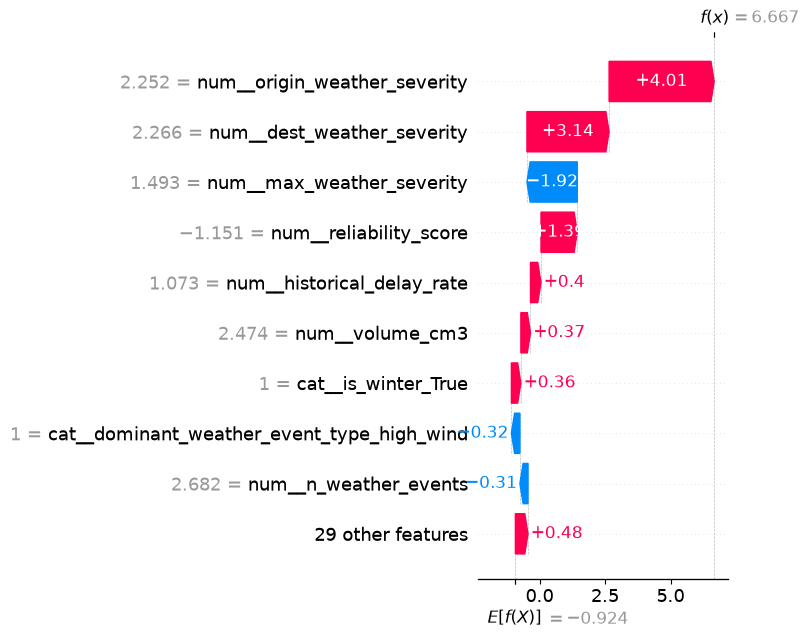

In [32]:
# E2 - SHAP: explain the top 10 highest-risk shipments in the validation set
import shap

X_val_used = X_val_fs if 'selected_features' in best_key else X_val
best_preprocessor = best_model.named_steps['preprocessor']
best_classifier = best_model.named_steps['classifier']
best_feat_names = best_preprocessor.get_feature_names_out()

X_val_transformed = best_preprocessor.transform(X_val_used)
if hasattr(X_val_transformed, 'toarray'):
    X_val_transformed = X_val_transformed.toarray()
X_val_transformed = pd.DataFrame(X_val_transformed, columns=best_feat_names, index=X_val_used.index)

background = X_val_transformed.sample(n=min(100, len(X_val_transformed)), random_state=RANDOM_STATE)
explainer = shap.Explainer(best_classifier, background)
shap_values = explainer(X_val_transformed)

top10_idx = np.argsort(-best_prob)[:10]
top10_shipment_ids = master.loc[X_val_used.index[top10_idx], 'shipment_id'].values

for rank, (idx, sid) in enumerate(zip(top10_idx, top10_shipment_ids), start=1):
    print(f"\n#{rank} - shipment {sid}, predicted risk = {best_prob[idx]:.1%}")
    contrib = pd.Series(shap_values.values[idx], index=best_feat_names)
    print(contrib.reindex(contrib.abs().sort_values(ascending=False).index).head(5))

# Waterfall plot for the single highest-risk shipment as a visual example
shap.plots.waterfall(shap_values[top10_idx[0]], show=False)
plt.tight_layout()
plt.show()

**E2 interpretation**: for all 10 highest-risk shipments (predicted risk 98.7 - 99.9%), `origin_weather_severity` and `dest_weather_severity` are consistently the top two SHAP contributors, with `reliability_score` (a low-reliability carrier) close behind. These are shipments where a weather event and a weak carrier compound. `max_weather_severity` consistently shows a *negative* SHAP contribution despite the shipment being high-risk, which is the same multicollinearity artifact flagged in Section 7 (it duplicates information already carried by `origin_weather_severity`/`dest_weather_severity`, so SHAP nets out its marginal contribution as negative even though the shipment overall is high-risk).